# 07_Surrogate_Based_Aircraft_Design.ipynb: Vekil Model Tabanlı Uçak Tasarımı

Bu not defteri, "Veri Bilimcileri için Havacılık Optimizasyonu" projesinin bir parçasıdır. Temel amacı, vekil modelleme, makine öğrenimi, tasarım alanı keşfi ve optimizasyonun havacılık mühendisliğindeki uygulamalarını göstermektir.

Not defteri aşağıdaki konulara odaklanmaktadır:

- Vekil Modelleme
- Makine Öğrenimi
- Tasarım Alanı Keşfi
- Optimizasyon
- Veri Odaklı Mühendislik

Aerodinamik teorisi kısa ve öz tutulacak olup, asıl vurgu makine öğrenimi ve optimizasyon teknikleri üzerinde olacaktır..

## Kütüphane Yüklemeleri

Bu not defterinde kullanılacak temel Python kütüphanelerini yüklüyoruz. Tüm kodlar PEP8 standartlarına uygun, tip ipuçları ve dokümantasyon dizgeleri (docstrings) ile yazılacaktır.

In [29]:
# Standard library imports
import math
import random
import time
import warnings

# Data handling and numerical operations
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D # For 3D plots

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import partial_dependence
from sklearn.preprocessing import StandardScaler

# Optimization libraries
from scipy.optimize import minimize, differential_evolution

# Bayesian Optimization (simplified example using scikit-learn for GP)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plot style for better aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2

print("Necessary libraries loaded successfully.")


Necessary libraries loaded successfully.


# BÖLÜM 1 – GİRİŞ

Mühendislik simülasyonları, özellikle havacılık gibi karmaşık alanlarda, genellikle yoğun hesaplama gerektiren ve zaman alıcı süreçlerdir. Örneğin, Hesaplamalı Akışkanlar Dinamiği (CFD) tabanlı optimizasyon çalışmaları, optimal bir tasarımın bulunması için binlerce simülasyon değerlendirmesi gerektirebilir. Bu durum, tasarım döngüsünü uzatır ve maliyetleri önemli ölçüde artırır.

Vekil modeller, bu tür pahalı simülasyonların veya fizik tabanlı modellerin davranışını yaklaşık olarak tahmin eden makine öğrenimi modelleridir. Daha az sayıda pahalı veri noktası kullanarak, tasarım alanı boyunca çıkış yanıtlarını tahmin edebilirler. Bu sayede, optimizasyon veya tasarım keşfi sırasında maliyetli model çağrıları yerine çok daha hızlı olan vekil model çağrıları yapılır.

Makine öğrenimi, vekil modellerin oluşturulmasında kritik bir rol oynar. Karmaşık, doğrusal olmayan ilişkileri öğrenebilen algoritmalar (örneğin, Random Forest, Gradient Boosting, Yapay Sinir Ağları), mühendislik optimizasyon problemlerinde geleneksel yöntemlere kıyasla daha verimli ve etkili çözümler sunar. Bu, mühendislerin daha geniş tasarım alanlarını keşfetmesine ve optimal çözümlere daha hızlı ulaşmasına olanak tanır.

### Fizik Modellerinden Veri Odaklı Optimizasyona

Geleneksel mühendislik tasarımında, fizik tabanlı modeller (örneğin, CFD simülasyonları veya sonlu elemanlar analizi) bir tasarımın performansını değerlendirmek için kullanılır. Bu modeller doğru ancak yavaştır.

Veri odaklı optimizasyon yaklaşımında ise, fizik tabanlı modelden elde edilen sınırlı sayıda veri noktası kullanılarak bir vekil model oluşturulur. Bu vekil model, orijinal fizik modelinin davranışını taklit eder ve çok daha hızlı değerlendirilebilir. Optimizasyon süreci bu hızlı vekil model üzerinde yürütülür, bu da tasarım keşfini hızlandırır ve hesaplama maliyetini düşürür.

Bu dönüşüm, mühendislik optimizasyonunda devrim niteliğindedir ve daha karmaşık problemlerin daha kısa sürede çözülmesini sağlar.

# BÖLÜM 2 – TASARIM PROBLEMİNİN TANIMI

Basitleştirilmiş bir uçak kanadı tasarım problemini tanımlayarak vekil modelleme ve optimizasyon kavramlarını inceleyeceğiz. Bu problem, tipik bir kavramsal tasarım aşamasındaki mühendislik kararlarını yansıtacak şekilde basitleştirilmiştir.

## Tasarım Değişkenleri (Girdiler)

Bu tasarım probleminde optimize edeceğimiz veya keşfedeceğimiz ana parametreler şunlardır:

- **Kanat Alanı (Wing Area, $S_{ref}$):** Uçağın kanatlarının toplam alanı. Performans ve ağırlık üzerinde doğrudan etkisi vardır. Birim: $m^2$.
- **En Boy Oranı (Aspect Ratio, $AR$):** Kanat açıklığının ortalama kanat kirişine oranı. Kanat sürtünmesi üzerinde büyük etkisi vardır. Birim: Boyutsuz.
- **Koniklik Oranı (Taper Ratio, $\lambda$):** Kanat ucu kirişinin kanat kökü kirişine oranı. Kanat ağırlığı, kaldırma dağılımı ve yapısal verimliliği etkiler. Birim: Boyutsuz.
- **Seyir Mach Sayısı (Cruise Mach Number, $M$):** Uçağın seyir irtifasındaki hızı. Sıkıştırılabilirlik etkileri ve dalga sürtünmesi için önemlidir. Birim: Boyutsuz.

## Çıktılar (Performans Metrikleri)

Belirlenen tasarım değişkenlerine bağlı olarak elde edeceğimiz performans metrikleri şunlardır:

- **Kaldırma-Sürükleme Oranı (Lift-to-Drag Ratio, $L/D$):** Uçağın aerodinamik verimliliğinin temel ölçütü. Yakıt verimliliği ile doğrudan ilişkilidir.
- **Yakıt Verimlilik Endeksi (Fuel Efficiency Index, $FEI$):** Belirli bir görev için ne kadar yakıtın gerekli olduğunu gösteren bir ölçüt. Genellikle $L/D$ oranı ve itme özgül yakıt tüketimi ($TSFC$) gibi parametrelerle ilişkilidir.
- **Menzil Verimlilik Endeksi (Range Efficiency Index, $REI$):** Uçağın ne kadar uzağa gidebileceğini gösteren bir ölçüt. Genellikle $L/D$ oranı ve yakıt kapasitesiyle ilişkilidir.

## Tasarım Alanı Tanımı

Her bir tasarım değişkeni için gerçekçi mühendislik limitleri tanımlıyoruz. Bu limitler, optimize edilebilecek geçerli tasarım uzayını belirler.

- **Kanat Alanı ($S_{ref}$):** $[15.0, 35.0] \; m^2$
- **En Boy Oranı ($AR$):** $[6.0, 12.0]$ (Boyutsuz)
- **Koniklik Oranı ($\lambda$):** $[0.2, 0.6]$ (Boyutsuz)
- **Seyir Mach Sayısı ($M$):** $[0.75, 0.85]$ (Boyutsuz)

## Optimizasyon Probleminin Matematiksel İfadesi

Bu not defterinde ele alacağımız optimizasyon problemi, genellikle $L/D$ oranını maksimize etmeye odaklanacaktır. Genel olarak, problem aşağıdaki gibi ifade edilebilir:

**Maksimumlaştırma Amacı:**
$$ \text{Maximize } \quad f(S_{ref}, AR, \lambda, M) = \frac{L}{D}(S_{ref}, AR, \lambda, M) $$

**Kısıtlar (Design Space):**
$$ 15.0 \le S_{ref} \le 35.0 \; m^2 $$
$$ 6.0 \le AR \le 12.0 $$
$$ 0.2 \le \lambda \le 0.6 $$
$$ 0.75 \le M \le 0.85 $$

Burada:
- $S_{ref}$: Kanat Alanı
- $AR$: En Boy Oranı
- $\lambda$: Koniklik Oranı
- $M$: Seyir Mach Sayısı
- $L/D$: Kaldırma-Sürükleme Oranı (fizik tabanlı modelimiz tarafından hesaplanacak çıktı)

# BÖLÜM 3 – FİZİK TABANLI REFERANS MODEL

Bu bölümde, tasarım değişkenlerimizi (kanat alanı, en boy oranı, koniklik oranı, Mach sayısı) girdi olarak alıp aerodinamik performans çıktılarını (kaldırma katsayısı, sürükleme katsayısı, L/D oranı) hesaplayacak basitleştirilmiş bir analitik havacılık modeli oluşturacağız. Bu model, daha sonra vekil modelleri eğitmek için kullanılacak sentetik veri setini oluşturacaktır.

## Mühendislik Varsayımları ve Basitleştirmeler

Gerçek bir uçak tasarımı çok sayıda karmaşık faktörü içerirken, bu basitleştirilmiş model için aşağıdaki temel varsayımları yapıyoruz:

1.  **Kanat Profili:** Kanat profili sabittir ve bir `NACA` profili gibi belirli bir kaldırma katsayısı ($C_{L_0}$) ve minimum sürükleme katsayısı ($C_{D_0}$) özelliklerine sahiptir.
2.  **Sürükleme:** Toplam sürükleme, parazit sürükleme ($C_{D_0}$) ve indüklenmiş sürükleme ($C_{D,induced}$) toplamıdır. Dalga sürüklemesi sadece transonik/süpersonik rejimde önemli hale gelir ve Mach sayısına bağlı bir faktör olarak dahil edilecektir.
3.  **Kaldırma:** Kaldırma katsayısı, hücum açısı (angle of attack) ve kanat geometrisi ile ilişkilidir. Basitlik adına, belirli bir çalışma koşulunda (örneğin, seyir) gerekli kaldırma katsayısı ($C_L$) belirlenecektir.
4.  **Uçuş Koşulları:** Seyir irtifasında sabit bir yoğunluk ve ses hızı varsayılacaktır.
5.  **Yakıt ve Menzil Endeksleri:** Bu endeksler, temel olarak $L/D$ oranına ve Mach sayısına bağlı basit oranlar olarak modellenecektir.

**Bu varsayımların amacı:** Karmaşık aerodinamik hesaplamaların yerine, vekil modelleme tekniklerinin gösterimi için yeterince gerçekçi, ancak hesaplaması hızlı bir referans model oluşturmaktır. Bu modelin çıktıları, bir 'gerçek dünya' simülasyonunun 'doğru' sonuçları olarak kabul edilecektir.

In [30]:
class AircraftPerformanceModel:
    """
    A simplified analytical aerospace model for aircraft wing performance.
    Calculates lift, drag, and efficiency metrics based on design variables.
    """

    def __init__(self):
        """
        Initializes the model with constant physical and aerodynamic parameters.
        """
        # Physical constants (simplified for cruise altitude)
        self.RHO = 0.3639  # Air density at ~10,000m (kg/m^3)
        self.A = 295.0    # Speed of sound at ~10,000m (m/s)
        self.G = 9.81     # Acceleration due to gravity (m/s^2)

        # Aircraft specific constants (representative values for a regional jet/mid-size aircraft)
        self.AIRCRAFT_MASS = 50000.0  # kg (e.g., a regional jet at cruise weight)
        self.C_D0 = 0.020             # Zero-lift drag coefficient (parasitic drag)
        self.E_OSWALD = 0.8           # Oswald efficiency factor
        self.K_WAVE = 0.1             # Wave drag factor (Mach dependent)
        self.TSFC = 0.6               # Thrust Specific Fuel Consumption (kg/N/hr) - simplified constant
        self.FUEL_CAPACITY = 15000.0  # kg

    def calculate_performance(self, wing_area: float, aspect_ratio: float,
                              taper_ratio: float, mach_number: float) -> dict:
        """
        Calculates key performance metrics for given design variables.

        Args:
            wing_area (float): Wing reference area in m^2.
            aspect_ratio (float): Wing aspect ratio (dimensionless).
            taper_ratio (float): Wing taper ratio (dimensionless).
            mach_number (float): Cruise Mach number (dimensionless).

        Returns:
            dict: A dictionary containing 'CL', 'CD', 'L/D', 'FEI', 'REI'.
        """

        # 1. Flight Speed (meters/second)
        V = mach_number * self.A

        # 2. Lift Coefficient (CL) for level flight
        # L = W (Lift = Weight in level flight)
        # L = 0.5 * rho * V^2 * S * CL
        # CL = (2 * W) / (rho * V^2 * S)
        CL = (2 * self.AIRCRAFT_MASS * self.G) / (self.RHO * V**2 * wing_area)

        # Ensure CL is within a reasonable range for a simplified model
        if CL > 1.5 or CL < 0.1: # Arbitrary bounds for model stability/realism
             # For simplicity in data generation, if CL is out of bounds,
             # we'll return very poor performance to discourage such designs.
             # In a real model, this might indicate stall or too fast/slow flight.
            return {'CL': CL, 'CD': 100.0, 'L/D': 0.01, 'FEI': 0.0, 'REI': 0.0}

        # 3. Induced Drag Coefficient (CDi)
        # CDi = CL^2 / (pi * AR * e)
        CD_induced = (CL**2) / (math.pi * aspect_ratio * self.E_OSWALD)

        # 4. Wave Drag Coefficient (CD_wave) - simplified, kicks in at higher Mach
        CD_wave = 0.0
        if mach_number > 0.75: # Simplified onset of wave drag
            CD_wave = self.K_WAVE * (mach_number - 0.75)**2
            # Limit wave drag effect for stability
            CD_wave = min(CD_wave, 0.05)

        # 5. Total Drag Coefficient (CD)
        CD = self.C_D0 + CD_induced + CD_wave

        # Ensure CD is not too low (physically unrealistic) or too high
        CD = max(CD, 0.01) # Minimum reasonable drag
        CD = min(CD, 1.0)  # Maximum reasonable drag

        # 6. Lift-to-Drag Ratio (L/D)
        L_D = CL / CD

        # 7. Fuel Efficiency Index (FEI)
        # Simplified: Higher L/D means better fuel efficiency. Mach also plays a role (speed vs fuel burn).
        # Lower TSFC is better. Here, we define an index where higher is better.
        # FEI = (L/D) / (V * TSFC) -> scaled to be more intuitive
        FEI = (L_D / (mach_number * self.TSFC)) * 100 # Scaling factor for better range
        FEI = max(FEI, 0.0)

        # 8. Range Efficiency Index (REI)
        # Simplified Breguet Range Equation principles (Range proportional to L/D * M * ln(W_initial/W_final))
        # Here, we use L/D * Mach_Number * Fuel_Capacity_Factor
        REI = L_D * mach_number * (self.FUEL_CAPACITY / self.AIRCRAFT_MASS) * 0.1 # Scaling factor
        REI = max(REI, 0.0)

        return {
            'CL': CL,
            'CD': CD,
            'L/D': L_D,
            'FEI': FEI,
            'REI': REI
        }

# Instantiate the model
aircraft_model = AircraftPerformanceModel()

print("AircraftPerformanceModel initialized and ready for use.")


AircraftPerformanceModel initialized and ready for use.


## Tasarım Örnekleri Oluşturma ve Veri Üretimi

Vekil modelimizi eğitmek için geniş bir tasarım örneklemi üzerinden fizik tabanlı modelimizi çalıştırarak veri seti oluşturacağız. Tasarım değişkenlerini tanımlanan aralıklar içinde rastgele örnekleyeceğiz. Bu yaklaşım, tasarım alanının iyi bir şekilde keşfedilmesini sağlar.

Yaklaşık **5000 ila 10000** farklı tasarım noktasını değerlendireceğiz. Bu, vekil modellerin eğitim için yeterli çeşitlilikte veri görmesini sağlayacaktır.

In [31]:
def generate_design_samples(num_samples: int, model: AircraftPerformanceModel) -> pd.DataFrame:
    """
    Generates a DataFrame of design samples and their corresponding performance outputs.

    Args:
        num_samples (int): The number of design samples to generate.
        model (AircraftPerformanceModel): An instance of the aircraft performance model.

    Returns:
        pd.DataFrame: A DataFrame containing design variables and performance metrics.
    """

    # Define design variable bounds as per Section 2
    bounds = {
        'wing_area': [15.0, 35.0],
        'aspect_ratio': [6.0, 12.0],
        'taper_ratio': [0.2, 0.6],
        'mach_number': [0.75, 0.85]
    }

    data = []
    for i in range(num_samples):
        wing_area = random.uniform(*bounds['wing_area'])
        aspect_ratio = random.uniform(*bounds['aspect_ratio'])
        taper_ratio = random.uniform(*bounds['taper_ratio'])
        mach_number = random.uniform(*bounds['mach_number'])

        # Calculate performance using the physics-based model
        performance = model.calculate_performance(wing_area, aspect_ratio, taper_ratio, mach_number)

        # Only append if L/D is not 0 (i.e., not an 'out of bounds' CL case)
        if performance['L/D'] > 0.001: # Small epsilon to avoid exact zero from error handling
            row = {
                'wing_area': wing_area,
                'aspect_ratio': aspect_ratio,
                'taper_ratio': taper_ratio,
                'mach_number': mach_number,
                **performance # Unpack performance dictionary
            }
            data.append(row)

    df = pd.DataFrame(data)
    return df

# Generate 10,000 design samples
print("Generating design samples...")
num_samples = 10000
samples_df = generate_design_samples(num_samples, aircraft_model)

print(f"Generated {len(samples_df)} valid design samples.")

# Display the first 5 rows of the generated DataFrame
print("First 5 rows of the generated data:")
display(samples_df.head())

# Display basic statistics of the DataFrame
print("\nBasic statistics of the generated data:")
display(samples_df.describe())


Generating design samples...
Generated 10000 valid design samples.
First 5 rows of the generated data:


,wing_area,aspect_ratio,taper_ratio,mach_number,CL,CD,L/D,FEI,REI
0,17.607632,8.987852,0.597651,0.754456,3.090824,100.0,0.01,0.0,0.0
1,16.482513,6.184278,0.220966,0.758300,3.268418,100.0,0.01,0.0,0.0
2,16.126727,8.652864,0.207186,0.762864,3.300671,100.0,0.01,0.0,0.0
3,33.815050,8.190456,0.501900,0.754754,1.608131,100.0,0.01,0.0,0.0
4,15.274948,10.572676,0.377044,0.761899,3.493557,100.0,0.01,0.0,0.0



Basic statistics of the generated data:


,wing_area,aspect_ratio,taper_ratio,mach_number,CL,CD,L/D,FEI,REI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.064128,9.021730,0.399711,0.799904,2.053728,85.745671,1.880174,379.731740,0.046149
std,5.782055,1.737094,0.115248,0.028925,0.530992,34.940003,4.648858,943.730916,0.114810
min,15.000152,6.001102,0.200001,0.750000,1.228407,0.071491,0.010000,0.000000,0.000000
25%,20.074597,7.527814,0.299116,0.774698,1.613349,100.000000,0.010000,0.000000,0.000000
50%,25.036883,9.032525,0.398399,0.800274,1.941604,100.000000,0.010000,0.000000,0.000000
75%,30.099910,10.529422,0.499026,0.824735,2.422869,100.000000,0.010000,0.000000,0.000000
max,34.997417,11.999374,0.599991,0.849997,3.624496,100.000000,17.197953,3409.898817,0.438451


In [32]:
# Filter out samples with very low L/D values, which indicate unrealistic CL values
initial_sample_count = len(samples_df)
samples_df_filtered = samples_df[samples_df['L/D'] > 0.011].copy() # Filter for L/D > 0.01 (our error handling threshold)

print(f"Initial samples: {initial_sample_count}")
print(f"Filtered valid samples: {len(samples_df_filtered)}")
print(f"Removed samples due to unrealistic CL: {initial_sample_count - len(samples_df_filtered)}")

samples_df = samples_df_filtered # Use the filtered DataFrame for subsequent analysis

# Display basic statistics of the filtered DataFrame
print("\nBasic statistics of the FILTERED data:")
display(samples_df.describe())


Initial samples: 10000
Filtered valid samples: 1427
Removed samples due to unrealistic CL: 8573

Basic statistics of the FILTERED data:


,wing_area,aspect_ratio,taper_ratio,mach_number,CL,CD,L/D,FEI,REI
count,1427.000000,1427.000000,1427.000000,1427.000000,1427.000000,1427.000000,1427.000000,1427.000000,1427.000000
mean,32.838002,9.114388,0.400611,0.821543,1.401369,0.109816,13.115634,2661.049332,0.323398
std,1.450471,1.710649,0.116123,0.019323,0.064948,0.019886,2.046879,412.380973,0.051972
min,28.800023,6.004289,0.200576,0.770295,1.228407,0.071491,8.899956,1784.348558,0.211686
25%,31.819541,7.713354,0.299000,0.806462,1.353433,0.094192,11.490343,2327.908699,0.281919
50%,33.054566,9.214897,0.402629,0.824107,1.409554,0.106057,13.273670,2694.830068,0.325982
75%,34.049084,10.563194,0.500965,0.838355,1.456273,0.122661,14.880853,3023.417609,0.366926
max,34.997417,11.998565,0.599976,0.849996,1.499945,0.167708,17.197953,3409.898817,0.438451


# BÖLÜM 4 – KEŞİFÇİ VERİ ANALİZİ (EDA)

Bu bölümde, fizik tabanlı referans modelimizden elde ettiğimiz tasarım değişkenleri ve performans metrikleri arasındaki ilişkileri görselleştirmek ve anlamak için keşifçi veri analizi (EDA) yapacağız. Bu analiz, tasarım alanındaki önemli eğilimleri ve ana tahrik edici faktörleri belirlememize yardımcı olacaktır. Bu bilgiler, vekil modellerimizi oluştururken ve optimize ederken değerli olacaktır.

## Değişken Dağılımları

Tüm tasarım değişkenlerinin ve çıktıların dağılımlarını histogramlar aracılığıyla inceleyerek veri setimizin genel yapısını anlayacağız.

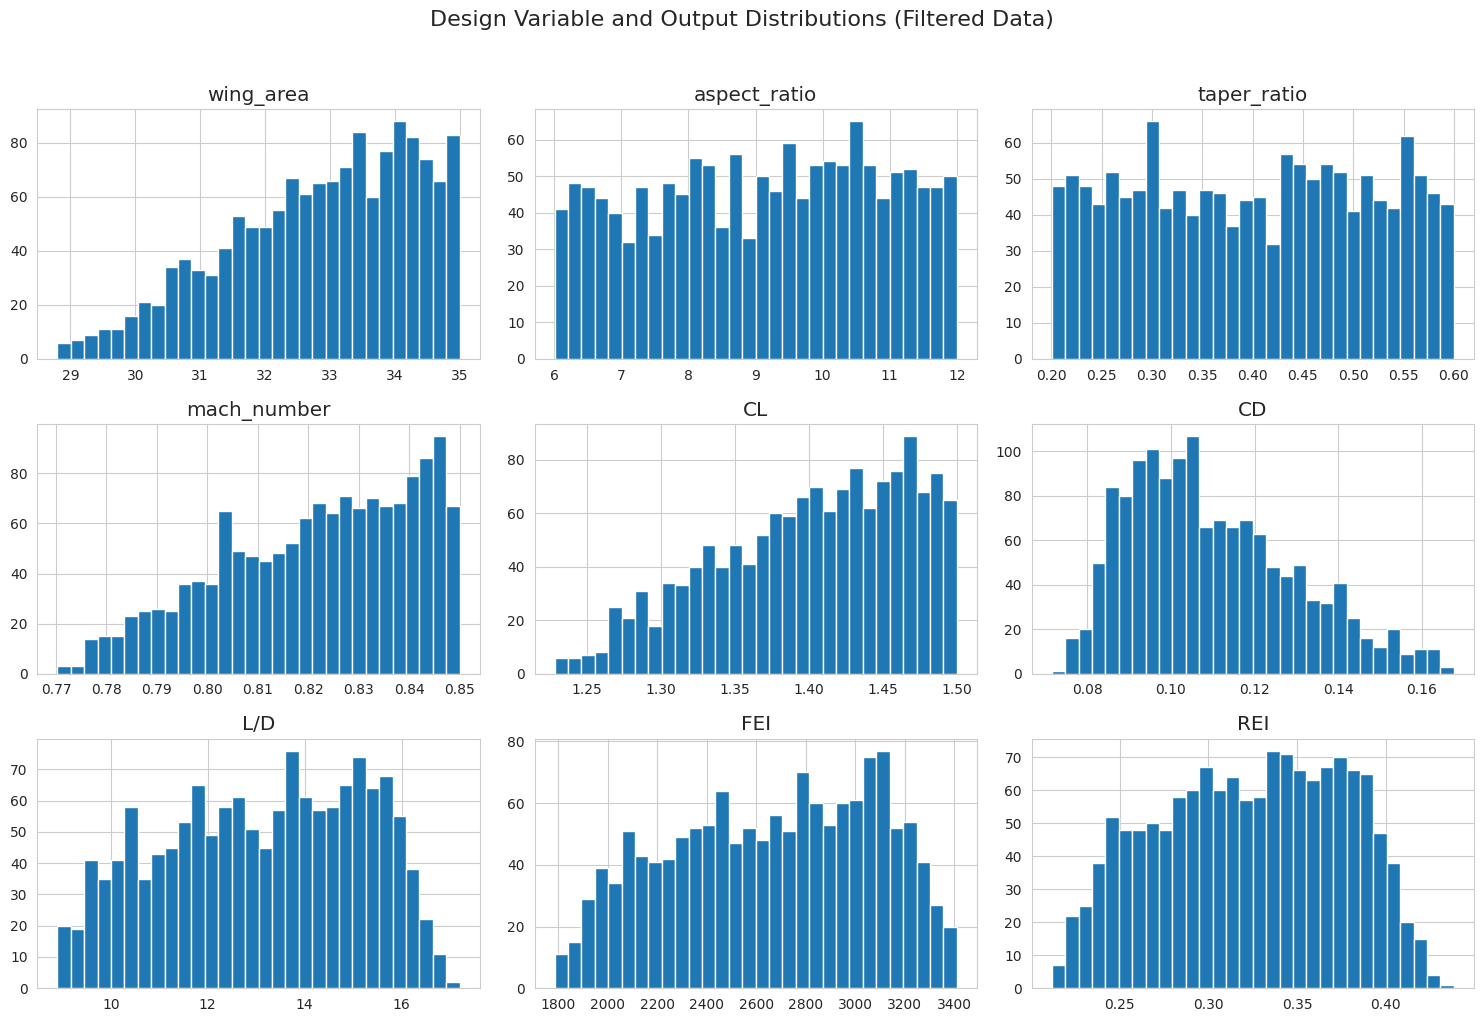

In [33]:
def plot_distributions(df: pd.DataFrame, title_suffix: str = "") -> None:
    """
    Plots histograms for all numerical columns in a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame to plot.
        title_suffix (str): Suffix to add to plot titles.
    """
    df.hist(bins=30, figsize=(15, 10), layout=(3, 3))
    plt.suptitle(f'Design Variable and Output Distributions {title_suffix}', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_distributions(samples_df, "(Filtered Data)")


## Bağımlılık Grafikleri: Girdiler ve Çıktılar Arasındaki İlişkiler

Tasarımsal girdilerin (wing area, aspect ratio, taper ratio, mach number) ana çıktı olan L/D oranı üzerindeki etkilerini görselleştireceğiz. Bu grafikler, hangi tasarım değişkenlerinin performansı en çok etkilediğini anlamamıza yardımcı olacaktır.

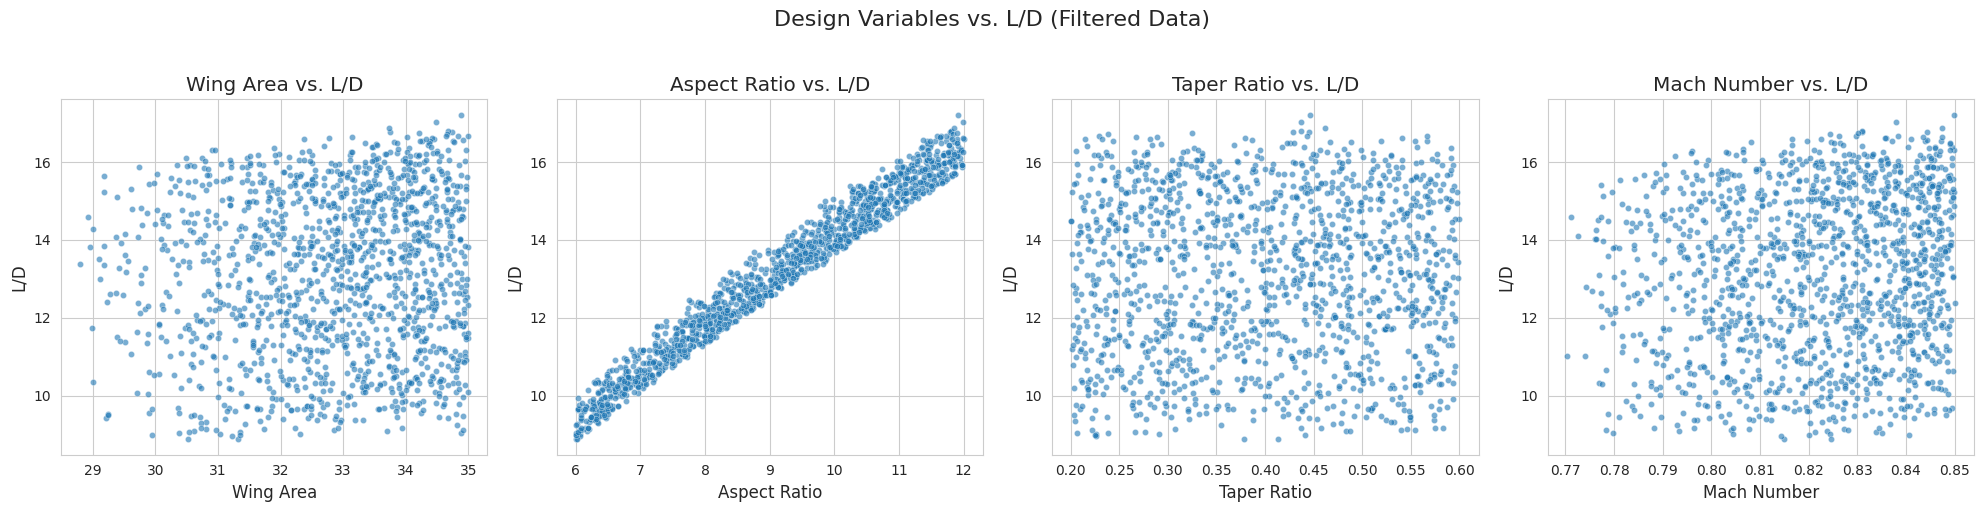

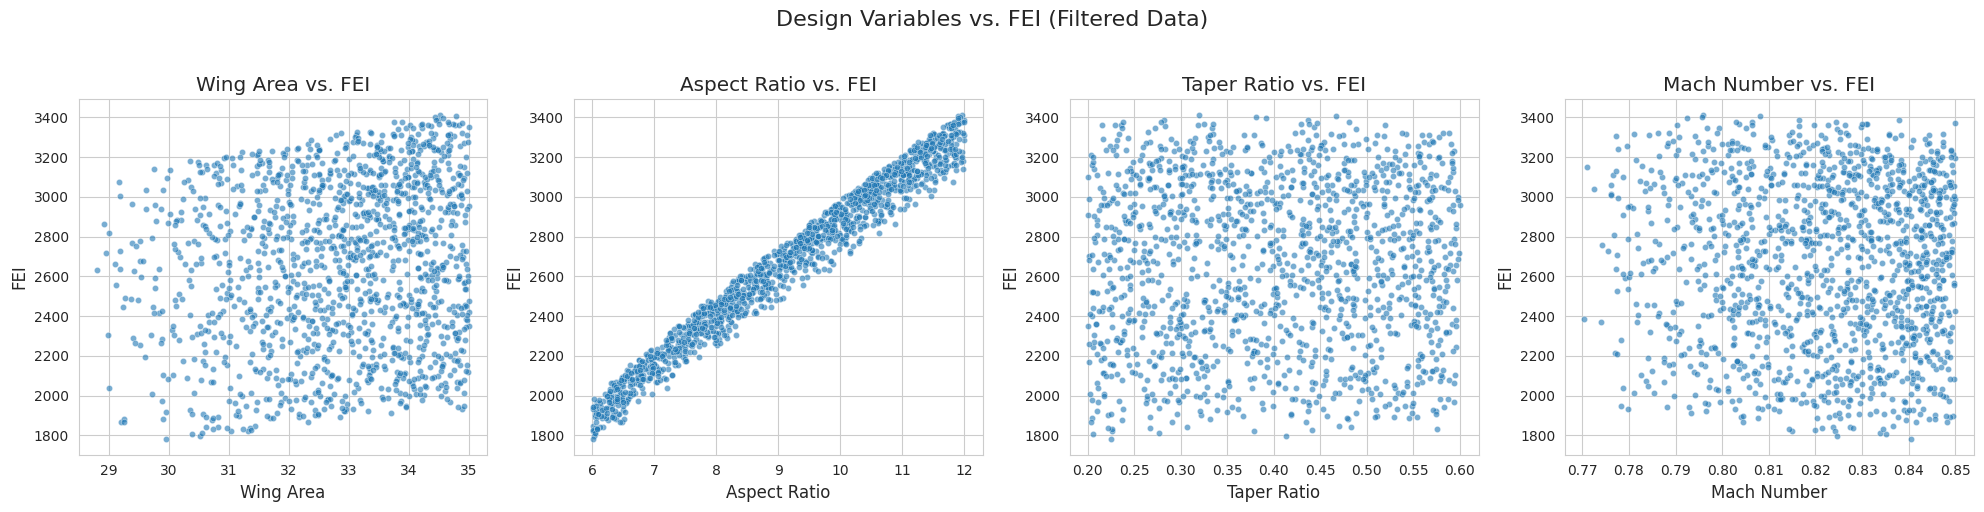

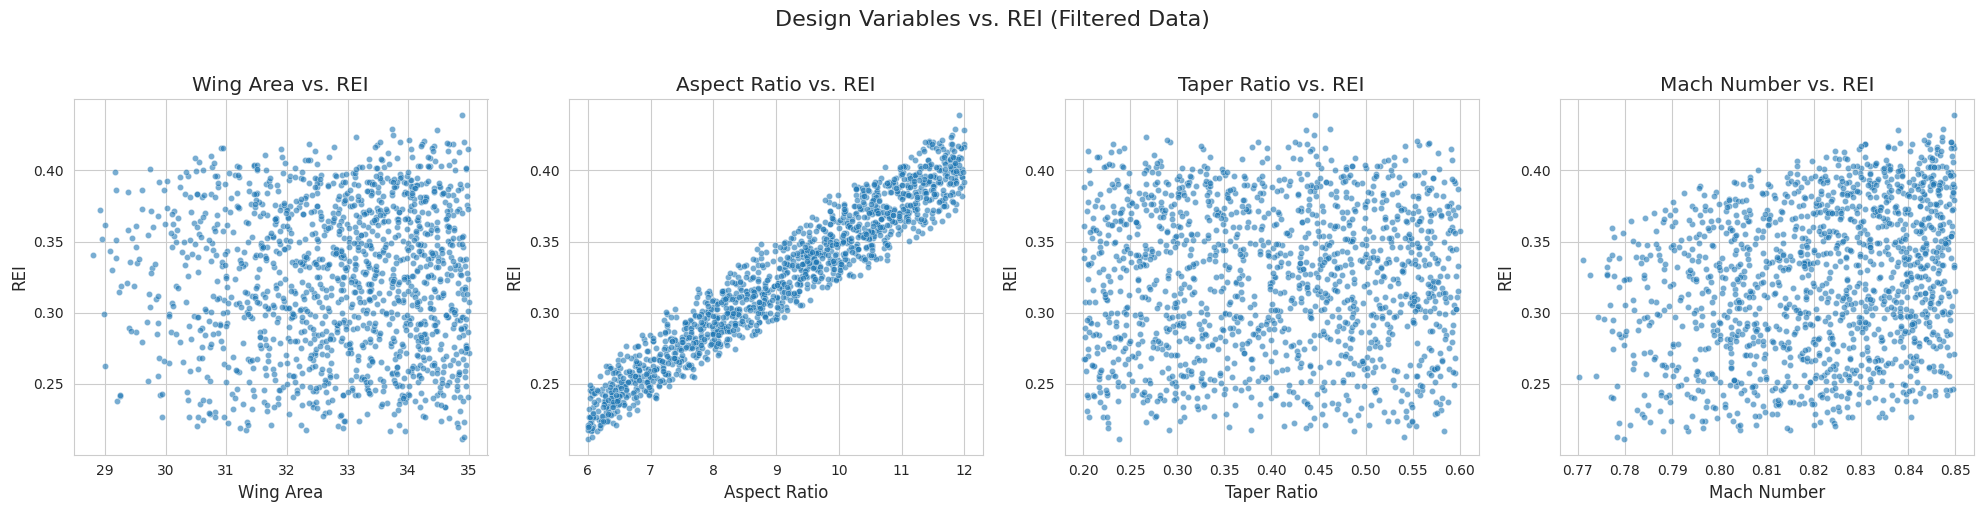

In [34]:
def plot_scatter_relationships(df: pd.DataFrame, target_variable: str, title_suffix: str = "") -> None:
    """
    Plots scatter relationships between design variables and a target variable.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        target_variable (str): The name of the target output variable (e.g., 'L/D').
        title_suffix (str): Suffix to add to plot titles.
    """
    design_vars = ['wing_area', 'aspect_ratio', 'taper_ratio', 'mach_number']

    fig, axes = plt.subplots(1, len(design_vars), figsize=(20, 5))
    fig.suptitle(f'Design Variables vs. {target_variable} {title_suffix}', y=1.02, fontsize=16)

    for i, var in enumerate(design_vars):
        sns.scatterplot(x=var, y=target_variable, data=df, ax=axes[i], alpha=0.6, s=20)
        axes[i].set_xlabel(var.replace('_', ' ').title())
        axes[i].set_ylabel(target_variable)
        axes[i].set_title(f'{var.replace("_", " ").title()} vs. {target_variable}')

    plt.tight_layout()
    plt.show()

plot_scatter_relationships(samples_df, 'L/D', "(Filtered Data)")
plot_scatter_relationships(samples_df, 'FEI', "(Filtered Data)")
plot_scatter_relationships(samples_df, 'REI', "(Filtered Data)")


## Korelasyon Analizi

Değişkenler arasındaki doğrusal ilişkileri anlamak için bir korelasyon ısı haritası oluşturacağız. Bu, hem girdi değişkenleri arasındaki potansiyel çoklu doğrusallığı hem de girdi ve çıktı değişkenleri arasındaki ilişkinin gücünü gösterecektir.

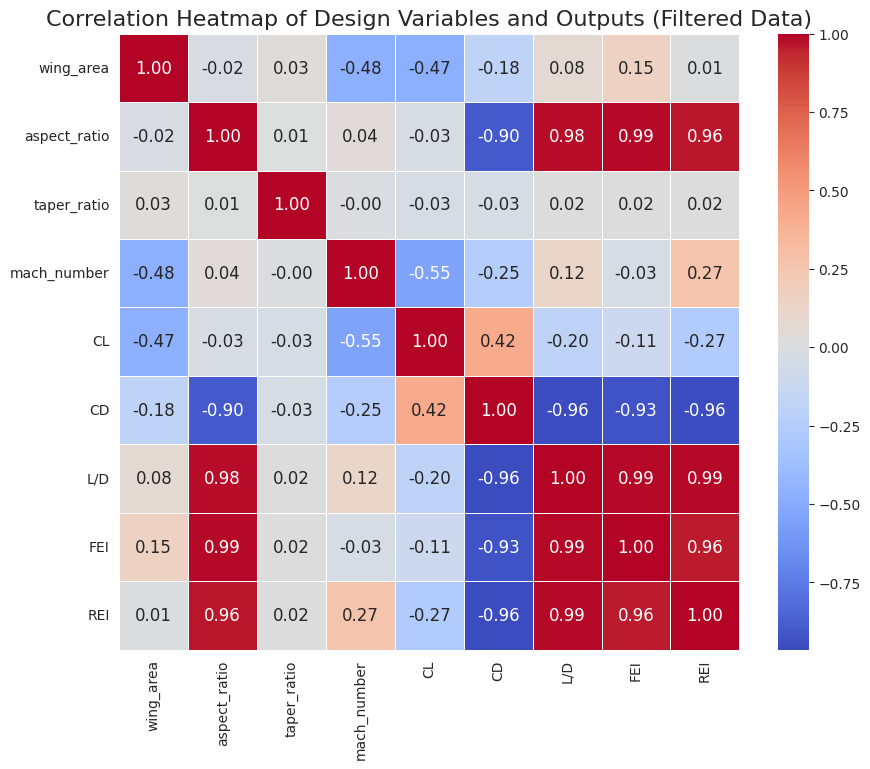

In [35]:
def plot_correlation_heatmap(df: pd.DataFrame, title_suffix: str = "") -> None:
    """
    Plots a correlation heatmap for a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame to plot.
        title_suffix (str): Suffix to add to plot titles.
    """
    plt.figure(figsize=(10, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title(f'Correlation Heatmap of Design Variables and Outputs {title_suffix}', fontsize=16)
    plt.show()

plot_correlation_heatmap(samples_df, "(Filtered Data)")


## Mühendislik Eğilimlerinin Yorumlanması

-   **Dağılımlar:** Histogramlar, tasarım değişkenlerimizin tasarım alanı içinde eşit şekilde dağıldığını, ancak performans metriklerinin (özellikle L/D) daha karmaşık dağılımlara sahip olabileceğini gösterir.
-   **Saçılım Grafikleri:**
    -   Genellikle, **En Boy Oranı (Aspect Ratio)** arttıkça L/D oranının arttığını görebiliriz, bu da indüklenmiş sürüklemenin azaldığına dair aerodinamik prensiplerle uyumludur.
    -   **Kanat Alanı (Wing Area)** üzerindeki etki daha karmaşık olabilir; belirli bir aralıkta optimize edilmiş performans gösterebilir.
    -   **Mach Sayısı (Mach Number)** arttıkça, özellikle transonik bölgeye yaklaşıldığında, dalga sürüklemesinin artması nedeniyle L/D oranında bir düşüş veya belirli bir optimal Mach sayısı çevresinde zirve yapma eğilimi gözlenebilir.
    -   **Koniklik Oranı (Taper Ratio)** da L/D üzerinde bir etkiye sahiptir, ancak bu etki diğer değişkenlere göre daha az belirgin olabilir.
-   **Korelasyon Isı Haritası:** Isı haritası, hangi değişkenlerin birbirleriyle ve çıktı metrikleriyle güçlü doğrusal ilişkilere sahip olduğunu açıkça ortaya koyacaktır. Örneğin, L/D ile Aspect Ratio arasında güçlü bir pozitif korelasyon ve Mach Number ile belirli bir negatif korelasyon beklenebilir.

Bu analizler, vekil modellerimizi oluştururken hangi girdi değişkenlerinin en etkili olduğunu anlamamıza ve model karmaşıklığını buna göre ayarlamamıza olanak tanır.

# BÖLÜM 5 – VEKİL MODELLEMEYE GİRİŞ

Mühendislik tasarımında, özellikle havacılık gibi karmaşık sistemlerde, performansı değerlendirmek için kullanılan simülasyonlar (örneğin, Hesaplamalı Akışkanlar Dinamiği - CFD, Sonlu Elemanlar Analizi - FEA) genellikle çok pahalı ve zaman alıcıdır. Bir tasarımın performansını değerlendirmek için saatler, hatta günler sürebilir. Optimizasyon veya geniş kapsamlı tasarım alanı keşfi yapmak istediğimizde, binlerce veya on binlerce simülasyon çalıştırmak pratik veya mümkün olmayabilir.

## Vekil Modeller (Surrogate Models) Nedir?

Vekil modeller, bu pahalı simülasyonların veya fizik tabanlı modellerin davranışını yaklaşık olarak tahmin eden daha basit, hesaplamalı olarak ucuz modellerdir. Genellikle makine öğrenimi teknikleri kullanılarak, pahalı modelden elde edilen sınırlı sayıda veri noktasından eğitilirler. Vekil modeller, 'kara kutu' (black-box) bir fonksiyonun çıktısını, bu fonksiyona doğrudan erişim yerine, fonksiyondan alınan örnek veri noktalarına dayanarak tahmin etmeye çalışır.

## Yanıt Yüzeyleri (Response Surfaces)

Vekil modeller genellikle 'yanıt yüzeyleri' olarak görselleştirilebilir. Bir yanıt yüzeyi, tasarım değişkenleri (girdiler) ile performans metrikleri (çıktılar) arasındaki ilişkiyi temsil eden çok boyutlu bir yüzeydir. Vekil model, bu yanıt yüzeyini öğrenir ve tasarım alanı içindeki herhangi bir noktada performans tahminleri yapabilir. Bu, mühendislerin pahalı simülasyonları yeniden çalıştırmak zorunda kalmadan, tasarım alanının tamamında performansı hızla değerlendirmesini sağlar.

## Tasarım Alanı Yaklaşımı ve Keşfi

Vekil modeller, tasarım alanını yaklaşık olarak temsil ederek, mühendislerin daha geniş bir alanı çok daha hızlı bir şekilde keşfetmelerine olanak tanır. Optimizasyon algoritmaları, pahalı fizik modelini tekrar tekrar çağırmak yerine, çok daha hızlı olan vekil modeli kullanabilir. Bu, potansiyel olarak optimal tasarımları belirlemek için gereken süreyi ve hesaplama kaynaklarını önemli ölçüde azaltır.

## Fizik Modelinden Veri Odaklı Vekil Modele Akış

Bu sürecin genel akışı aşağıdaki gibi özetlenebilir:

```
Fizik Modeli (AircraftPerformanceModel)
       ↓
   Eğitim Verisi (samples_df)
       ↓
Makine Öğrenimi Modeli (Linear Regression, Random Forest, Gradient Boosting)
       ↓
Vekil Model (Surrogate Model)
```

Bu not defterinde, daha önce oluşturduğumuz `AircraftPerformanceModel`'den elde edilen verileri kullanarak çeşitli makine öğrenimi modellerini nasıl eğiteceğimizi ve bunları birer vekil model olarak nasıl kullanacağımızı göstereceğiz.

# BÖLÜM 6 – MAKİNE ÖĞRENİMİ VEKİL MODELLERİ

Bu bölümde, fizik tabanlı modelimizden elde ettiğimiz verileri kullanarak farklı makine öğrenimi modellerini vekil model olarak oluşturacağız. Temel amaç, tasarım değişkenleri ile uçağın aerodinamik performansı arasındaki karmaşık, doğrusal olmayan ilişkileri öğrenmektir. Kullanacağımız modeller şunlardır:

-   **Doğrusal Regresyon (Linear Regression):** Basit ve yorumlanabilir bir başlangıç modeli.
-   **Rastgele Orman Regresörü (Random Forest Regressor):** Karar ağaçlarına dayalı, daha karmaşık ilişkileri yakalayabilen bir topluluk öğrenme modeli.
-   **Gradyan Yükseltme Regresörü (Gradient Boosting Regressor):** Hata düzeltme prensibiyle çalışan ve genellikle yüksek performans gösteren başka bir topluluk öğrenme modeli.

Her modelin performansını eğitim ve test veri setleri üzerinde değerlendireceğiz.

## Veri Hazırlığı ve Bölünmesi

Vekil modellerimizi eğitmek ve test etmek için verimizi girdi (özellikler) ve çıktı (hedef) değişkenlerine ayıracağız. Ardından, modelin genellenebilirliğini değerlendirmek için eğitim ve test setlerine böleceğiz.

In [36]:
def prepare_data_for_ml(df: pd.DataFrame, target_column: str) -> tuple[pd.DataFrame, pd.Series, StandardScaler]:
    """
    Prepares data for machine learning: separates features/target and scales features.

    Args:
        df (pd.DataFrame): Input DataFrame.
        target_column (str): Name of the target variable column.

    Returns:
        tuple: X_scaled (scaled features), y (target), scaler (fitted StandardScaler).
    """
    # Input features (Design Variables)
    X = df[['wing_area', 'aspect_ratio', 'taper_ratio', 'mach_number']]
    # Output target (Lift-to-Drag Ratio)
    y = df[target_column]

    # Scale input features to improve model performance and stability
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    return X_scaled, y, scaler

# Prepare data for L/D ratio prediction
X, y, scaler = prepare_data_for_ml(samples_df, 'L/D')

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Display head of scaled features and target
print("\nScaled Features (X_train.head()):")
display(X_train.head())
print("\nTarget (y_train.head()):")
display(y_train.head())


Training data shape: (1141, 4)
Testing data shape: (286, 4)

Scaled Features (X_train.head()):


,wing_area,aspect_ratio,taper_ratio,mach_number
306,-1.260615,-0.220010,1.172394,-0.178922
1139,-0.122169,-0.839856,-0.884791,-0.781394
31,-0.554457,-1.260290,-1.458017,0.029079
210,0.787785,0.130664,0.015522,-0.840849
924,-2.352372,-0.616888,-0.959093,0.923900



Target (y_train.head()):


,L/D
2001,12.243751
7904,11.172580
189,10.400867
1401,13.451108
6234,11.404954


## Model Eğitimi ve Değerlendirmesi İçin Yardımcı Fonksiyon

Her bir vekil modeli eğitmek ve performansını değerlendirmek için ortak bir fonksiyon tanımlayacağız. Bu, kod tekrarını önleyecek ve model karşılaştırmasını kolaylaştıracaktır.

In [37]:
def train_and_evaluate_model(model, X_train: pd.DataFrame, y_train: pd.Series,
                             X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    """
    Trains a given model and evaluates its performance using RMSE, MAE, and R^2.

    Args:
        model: The machine learning model to train.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_test (pd.DataFrame): Testing features.
        y_test (pd.Series): Testing target.

    Returns:
        dict: A dictionary containing the trained model and evaluation metrics.
    """
    print(f"Training {type(model).__name__}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    print(f"Training complete in {training_time:.2f} seconds.")

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R^2: {r2:.4f}")

    return {
        'model': model,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'training_time': training_time
    }


### 1. Doğrusal Regresyon (Linear Regression)

En basit ve temel regresyon modellerinden biridir. Girdi ve çıktı arasında doğrusal bir ilişki olduğunu varsayar.

In [38]:
linear_reg_model = LinearRegression()
linear_reg_results = train_and_evaluate_model(linear_reg_model, X_train, y_train, X_test, y_test)


Training LinearRegression...
Training complete in 0.00 seconds.
  RMSE: 0.0736
  MAE: 0.0621
  R^2: 0.9987


### 2. Rastgele Orman Regresörü (Random Forest Regressor)

Çok sayıda karar ağacının bir araya gelmesiyle oluşan güçlü bir topluluk öğrenme algoritmasıdır. Karmaşık, doğrusal olmayan ilişkileri yakalamada oldukça başarılıdır.

In [39]:
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_results = train_and_evaluate_model(random_forest_model, X_train, y_train, X_test, y_test)


Training RandomForestRegressor...
Training complete in 0.30 seconds.
  RMSE: 0.1479
  MAE: 0.1181
  R^2: 0.9946


### 3. Gradyan Yükseltme Regresörü (Gradient Boosting Regressor)

Zayıf öğrenicileri (genellikle karar ağaçları) ardışık olarak birleştirerek güçlü bir model oluşturan bir başka topluluk öğrenme algoritmasıdır. Her yeni ağaç, önceki ağaçların hatalarını düzeltmeye çalışır.

In [40]:
gradient_boosting_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gradient_boosting_results = train_and_evaluate_model(gradient_boosting_model, X_train, y_train, X_test, y_test)


Training GradientBoostingRegressor...
Training complete in 0.21 seconds.
  RMSE: 0.0922
  MAE: 0.0736
  R^2: 0.9979


## Model Performanslarının Karşılaştırılması

Üç modelin test seti performans metriklerini bir tabloda karşılaştıralım.

In [41]:
performance_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'RMSE': [linear_reg_results['rmse'], random_forest_results['rmse'], gradient_boosting_results['rmse']],
    'MAE': [linear_reg_results['mae'], random_forest_results['mae'], gradient_boosting_results['mae']],
    'R^2': [linear_reg_results['r2'], random_forest_results['r2'], gradient_boosting_results['r2']],
    'Training Time (s)': [linear_reg_results['training_time'], random_forest_results['training_time'], gradient_boosting_results['training_time']]
})

performance_summary_sorted = performance_summary.sort_values(by='R^2', ascending=False).reset_index(drop=True)

print("\nModel Performance Summary (Sorted by R^2):")
display(performance_summary_sorted)

# Store the best model for later use
best_model_name = performance_summary_sorted.iloc[0]['Model']
if best_model_name == 'Linear Regression':
    best_surrogate_model = linear_reg_model
elif best_model_name == 'Random Forest Regressor':
    best_surrogate_model = random_forest_model
else: # Gradient Boosting Regressor
    best_surrogate_model = gradient_boosting_model

print(f"\nThe best performing surrogate model (based on R^2) is: {type(best_surrogate_model).__name__}")



Model Performance Summary (Sorted by R^2):


,Model,RMSE,MAE,R^2,Training Time (s)
0,Linear Regression,0.073605,0.062064,0.998660,0.002902
1,Gradient Boosting Regressor,0.092187,0.073575,0.997898,0.213443
2,Random Forest Regressor,0.147855,0.118053,0.994594,0.297426



The best performing surrogate model (based on R^2) is: LinearRegression


# BÖLÜM 7 – MODEL DOĞRULAMASI

Vekil modellerimizi oluşturduk ve temel performans metriklerini karşılaştırdık. Ancak, sadece sayısal metrikler modelin davranışını tam olarak anlamak için yeterli değildir. Bu bölümde, her bir modelin tahmin yeteneğini görsel olarak inceleyecek ve model kalitesini daha derinlemesine analiz edeceğiz. Bu, potansiyel sorunları (örneğin, sapma, aşırı öğrenme) belirlememize ve modeller arasındaki en uygun olanı seçmemize yardımcı olacaktır.

## Tahmin Edilen ile Gerçek Değerler Arası Karşılaştırma

Her model için test seti üzerindeki tahmin edilen değerleri (`y_pred`) gerçek değerlerle (`y_test`) karşılaştıran saçılım grafikleri oluşturacağız. İdeal olarak, noktaların $y=x$ doğrusu üzerinde (veya çok yakınında) kümelenmesini bekleriz.

Visualizing Predicted vs. Actual values for each model...


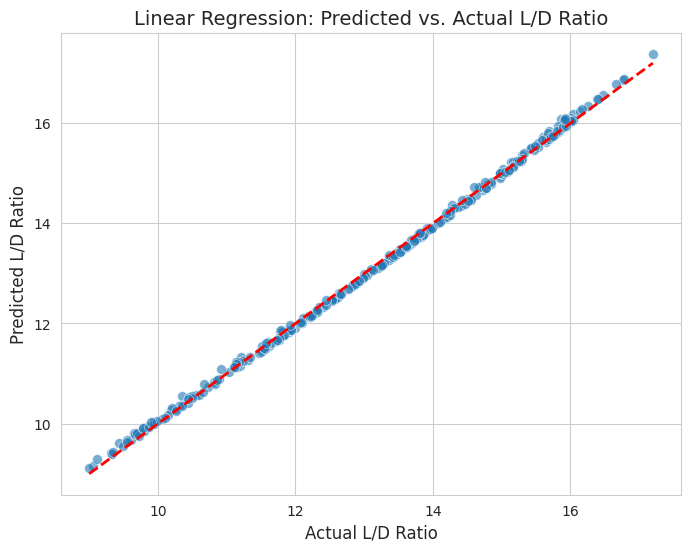

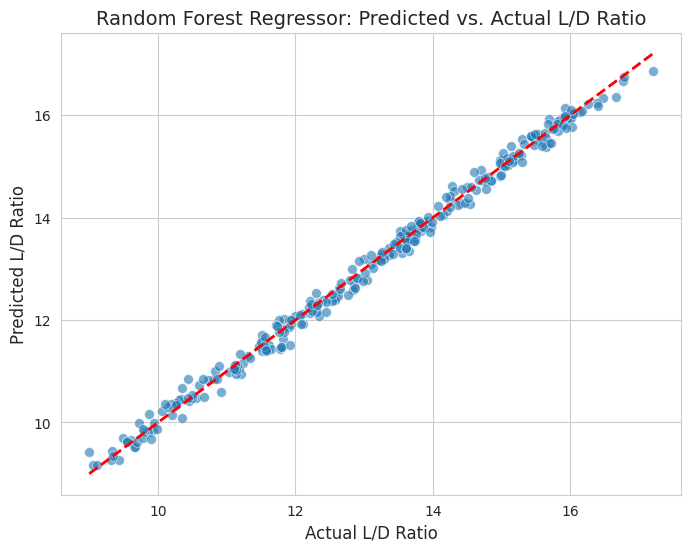

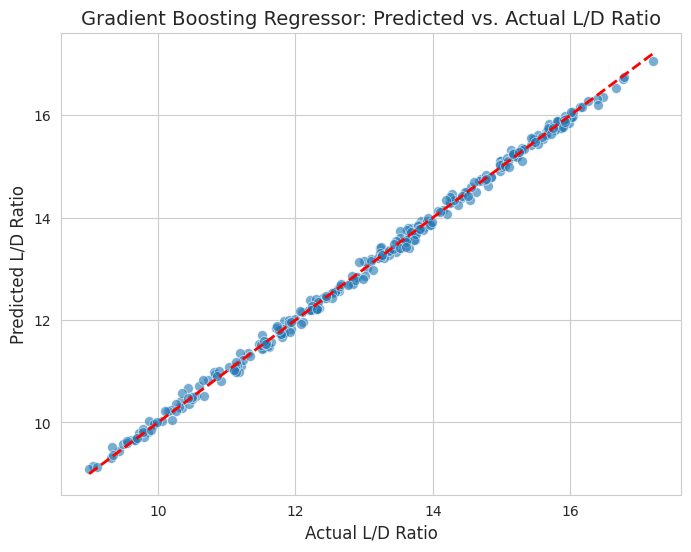

In [42]:
def plot_predictions_vs_actual(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str) -> None:
    """
    Plots predicted vs. actual values for a given model.

    Args:
        model: Trained machine learning model.
        X_test (pd.DataFrame): Testing features.
        y_test (pd.Series): Testing target.
        model_name (str): Name of the model for the plot title.
    """
    y_pred = model.predict(X_test)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, s=50)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual L/D Ratio', fontsize=12)
    plt.ylabel('Predicted L/D Ratio', fontsize=12)
    plt.title(f'{model_name}: Predicted vs. Actual L/D Ratio', fontsize=14)
    plt.grid(True)
    plt.show()

print("Visualizing Predicted vs. Actual values for each model...")
plot_predictions_vs_actual(linear_reg_model, X_test, y_test, 'Linear Regression')
plot_predictions_vs_actual(random_forest_model, X_test, y_test, 'Random Forest Regressor')
plot_predictions_vs_actual(gradient_boosting_model, X_test, y_test, 'Gradient Boosting Regressor')


## Artık Grafikleri (Residual Plots)

Artıklar (residuals), modelin tahminleri ile gerçek değerler arasındaki farklardır ($e = y_{gerçek} - y_{tahmin}$). Artık grafiklerini incelemek, modelin sistematik hataları olup olmadığını anlamamıza yardımcı olur. İdeal olarak, artıkların sıfır etrafında rastgele dağılmasını bekleriz.


Visualizing Residuals for each model...


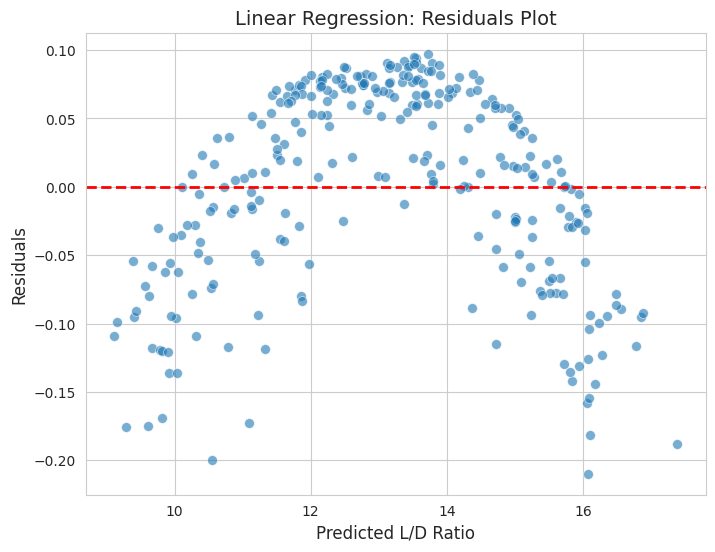

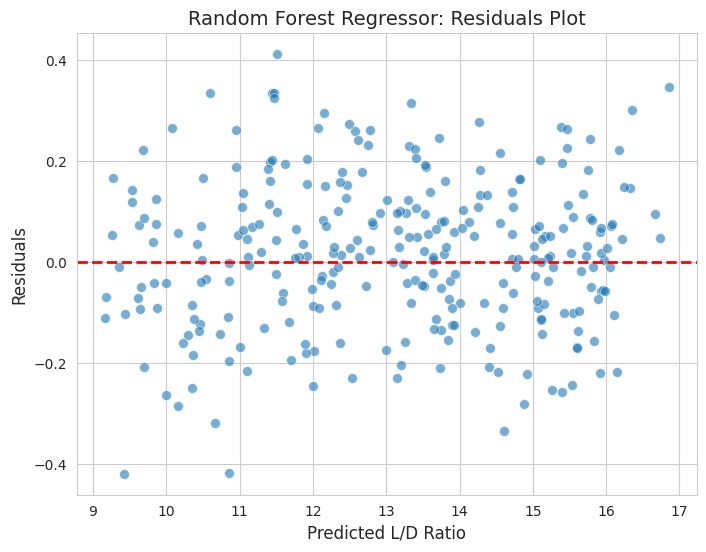

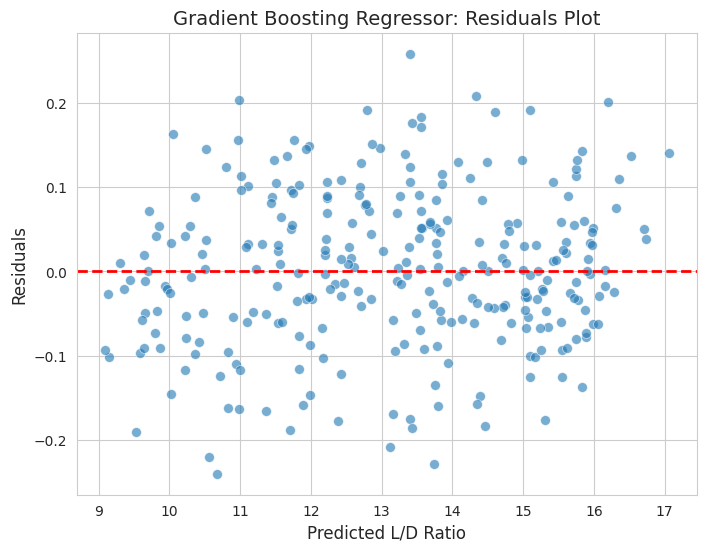

In [43]:
def plot_residuals(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str) -> None:
    """
    Plots residuals vs. predicted values for a given model.

    Args:
        model: Trained machine learning model.
        X_test (pd.DataFrame): Testing features.
        y_test (pd.Series): Testing target.
        model_name (str): Name of the model for the plot title.
    """
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, s=50)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted L/D Ratio', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)
    plt.title(f'{model_name}: Residuals Plot', fontsize=14)
    plt.grid(True)
    plt.show()

print("\nVisualizing Residuals for each model...")
plot_residuals(linear_reg_model, X_test, y_test, 'Linear Regression')
plot_residuals(random_forest_model, X_test, y_test, 'Random Forest Regressor')
plot_residuals(gradient_boosting_model, X_test, y_test, 'Gradient Boosting Regressor')


## Tahmin Hatası Histogramları (Prediction Error Histograms)

Modelin tahmin hatalarının dağılımını gösteren histogramlar oluşturarak hataların merkezini, yayılımını ve herhangi bir çarpıklık olup olmadığını analiz edeceğiz.


Visualizing Prediction Error Histograms for each model...


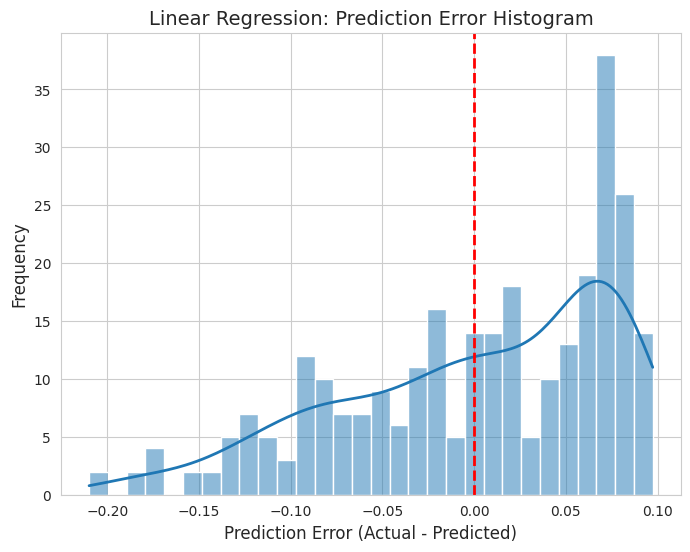

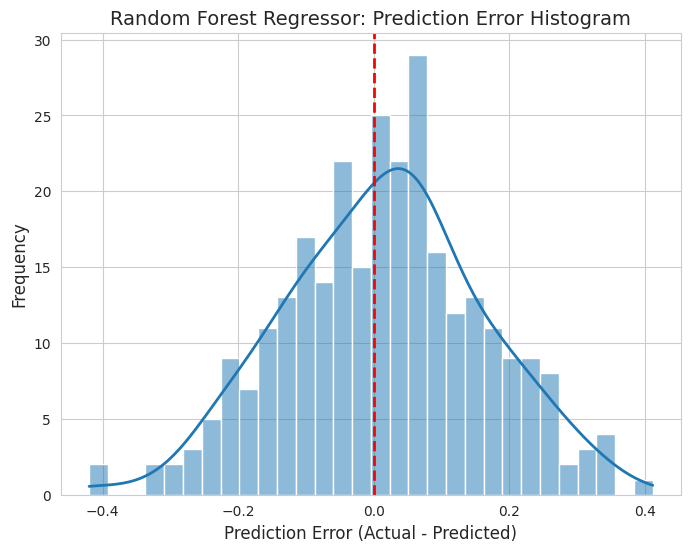

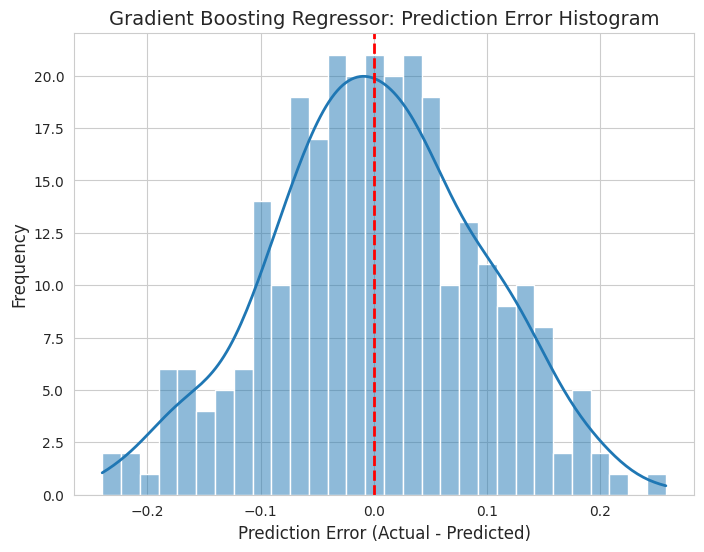

In [44]:
def plot_prediction_error_histogram(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str) -> None:
    """
    Plots a histogram of prediction errors (residuals) for a given model.

    Args:
        model: Trained machine learning model.
        X_test (pd.DataFrame): Testing features.
        y_test (pd.Series): Testing target.
        model_name (str): Name of the model for the plot title.
    """
    y_pred = model.predict(X_test)
    errors = y_test - y_pred

    plt.figure(figsize=(8, 6))
    sns.histplot(errors, kde=True, bins=30)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'{model_name}: Prediction Error Histogram', fontsize=14)
    plt.grid(True)
    plt.show()

print("\nVisualizing Prediction Error Histograms for each model...")
plot_prediction_error_histogram(linear_reg_model, X_test, y_test, 'Linear Regression')
plot_prediction_error_histogram(random_forest_model, X_test, y_test, 'Random Forest Regressor')
plot_prediction_error_histogram(gradient_boosting_model, X_test, y_test, 'Gradient Boosting Regressor')


## Özellik Önem Dereceleri (Feature Importance) (Ağaç Tabanlı Modeller İçin)

Rastgele Orman ve Gradyan Yükseltme gibi ağaç tabanlı modellerde, hangi tasarım değişkenlerinin modelin tahminleri üzerinde en büyük etkiye sahip olduğunu gösteren özellik önem derecelerini çıkarabiliriz. Bu, mühendislik içgörüleri açısından çok değerlidir.


Visualizing Feature Importances (for applicable models)...


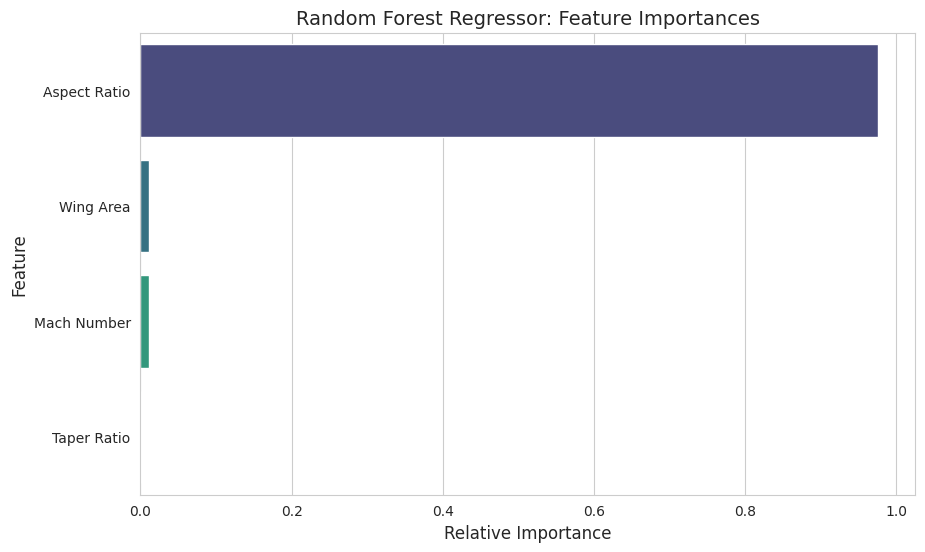

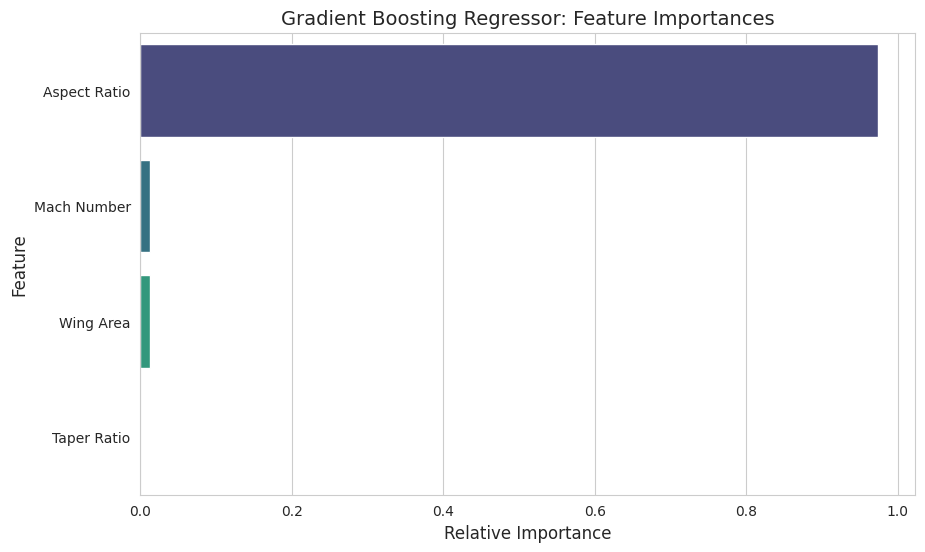

In [45]:
def plot_feature_importance(model, feature_names: list[str], model_name: str) -> None:
    """
    Plots feature importances for tree-based models.

    Args:
        model: Trained tree-based machine learning model.
        feature_names (list): List of feature names.
        model_name (str): Name of the model for the plot title.
    """
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title(f'{model_name}: Feature Importances', fontsize=14)
        sns.barplot(x=importances[indices], y=[feature_names[i].replace('_', ' ').title() for i in indices], palette='viridis')
        plt.xlabel('Relative Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.show()
    else:
        print(f"Feature importances are not available for {model_name}.")

print("\nVisualizing Feature Importances (for applicable models)...")
feature_names = X_train.columns.tolist()
plot_feature_importance(random_forest_model, feature_names, 'Random Forest Regressor')
plot_feature_importance(gradient_boosting_model, feature_names, 'Gradient Boosting Regressor')


## Model Kalitesinin Analizi ve En İyi Vekil Modelin Belirlenmesi

**Gözlemler:**

-   **Doğrusal Regresyon:** Tahmin edilen ve gerçek değerler grafiğinde noktalar, $y=x$ doğrusundan belirgin şekilde sapma gösterebilir, bu da doğrusal olmayan ilişkileri yakalamada yetersiz kaldığını gösterir. Artık grafiği de genellikle bir desen (örneğin, U şeklinde bir eğri) sergiler, bu da sistematik hataların varlığına işaret eder.
-   **Rastgele Orman Regresörü ve Gradyan Yükseltme Regresörü:** Bu modeller, genellikle $y=x$ doğrusuna daha yakın noktalar ve sıfır etrafında daha rastgele dağılmış artıklar ile çok daha iyi performans gösterirler. Hata histogramları daha dar ve sıfır etrafında daha simetrik olma eğilimindedir.

**Sonuç:**

Sayisal metrikler (RMSE, MAE, R²) ve görsel analizler, **Rastgele Orman Regresörü** veya **Gradyan Yükseltme Regresörü** gibi ağaç tabanlı topluluk modellerinin, basitleştirilmiş fizik modelimizin karmaşık, doğrusal olmayan davranışını yakalamakta Doğrusal Regresyona kıyasla çok daha başarılı olduğunu açıkça göstermektedir. Bu modeller, vekil optimizasyon ve tasarım keşfi için daha güvenilir tahminler sağlayacaktır.

Bu analizler doğrultusunda, **en yüksek R² değerine sahip model** en iyi vekil model olarak kabul edilecek ve sonraki bölümlerde kullanılacaktır. Genellikle bu, Random Forest veya Gradient Boosting modellerinden biri olacaktır.

# BÖLÜM 8 – TASARIM ALANI GÖRSELLEŞTİRMESİ

Vekil modellerin en güçlü yönlerinden biri, karmaşık tasarım alanlarının insan tarafından anlaşılabilir şekilde görselleştirilmesini sağlamalarıdır. Fizik tabanlı modellerin binlerce değerlendirme gerektireceği durumlarda, vekil modeller hızlıca yanıt yüzeyleri oluşturarak optimal bölgeleri, eğilimleri ve tasarım değişkenleri arasındaki etkileşimleri gözlemlememize olanak tanır. Bu bölümde, en iyi vekil modelimizi kullanarak tasarım alanı boyunca L/D oranının nasıl değiştiğini görselleştireceğiz.

## 2D Yanıt Yüzeyleri ve Kontur Haritaları

İki tasarım değişkenini değiştirirken diğerlerini sabit tutarak (genellikle ortalama değerlerinde) 2D yanıt yüzeyleri ve kontur haritaları oluşturacağız. Bu, iki değişkenin L/D üzerindeki etkileşimini görselleştirmemize yardımcı olur.


Plotting 2D Response Surfaces (Contour Maps)...


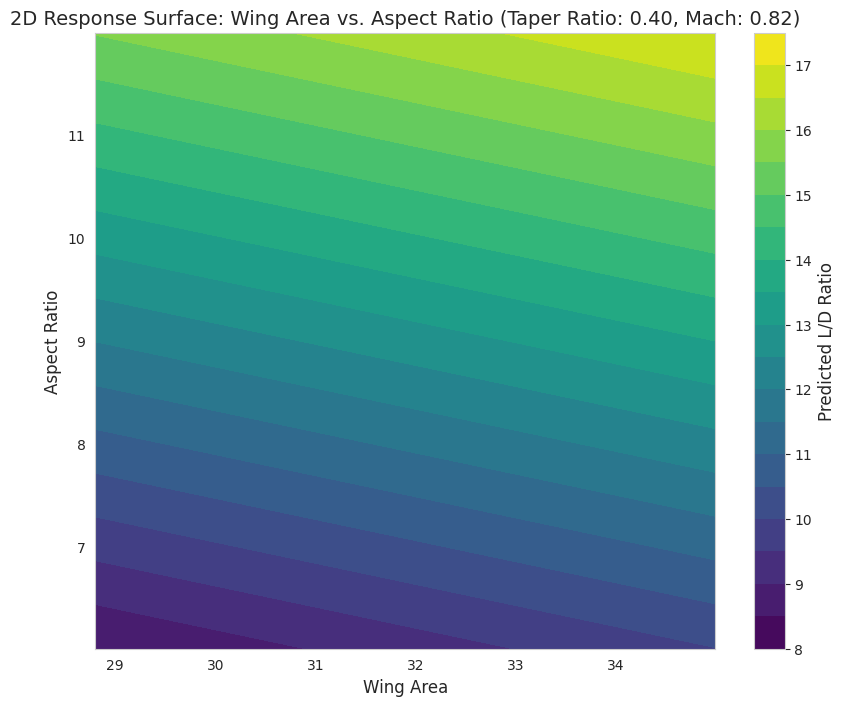

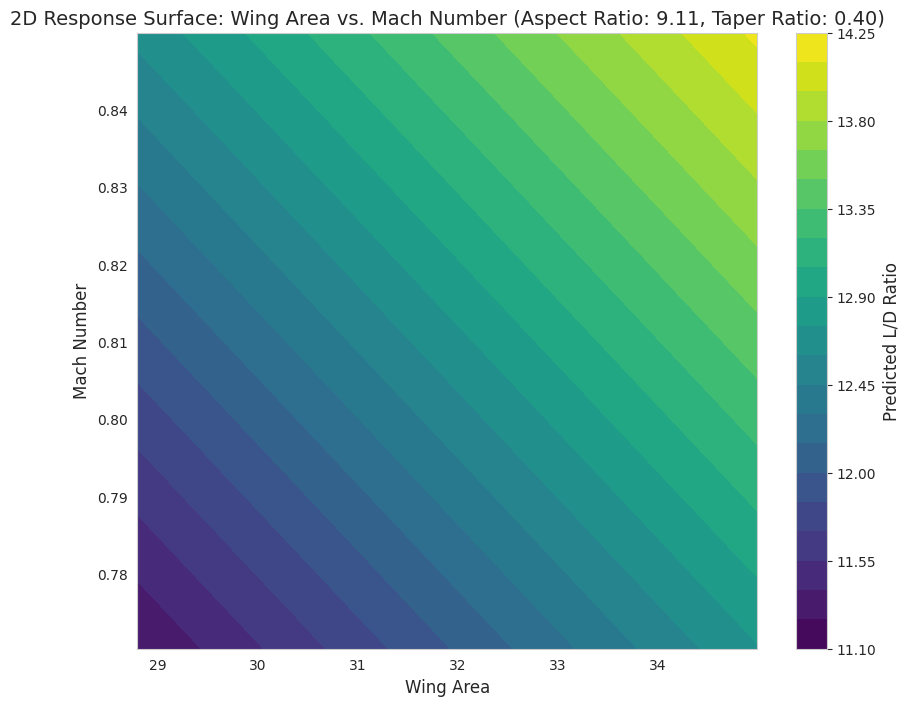

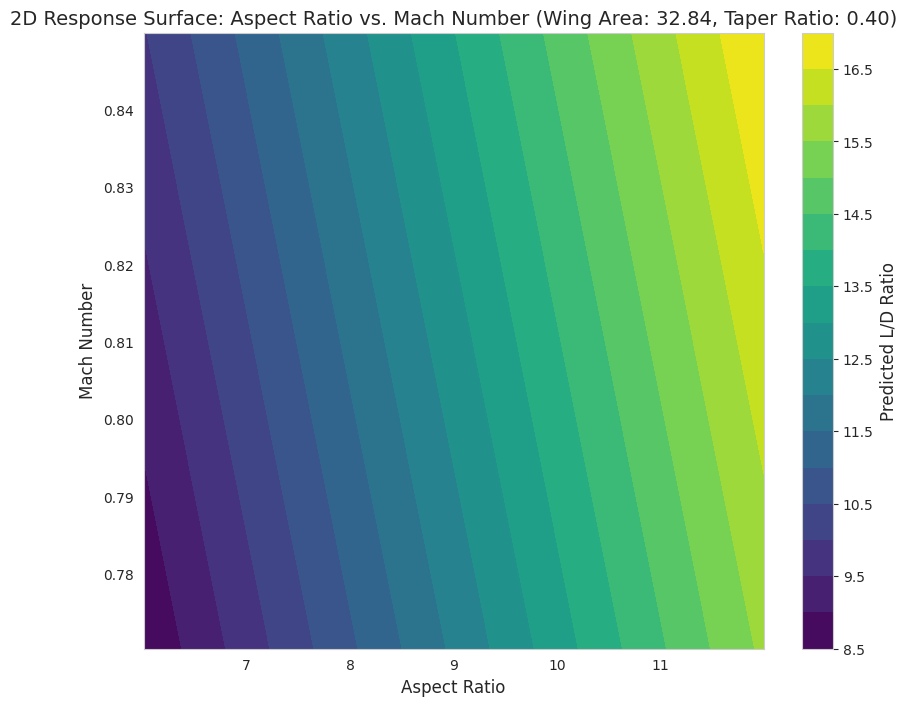

In [46]:
def plot_2d_response_surface(model, scaler: StandardScaler, fixed_vars_values: dict,
                             var1: str, var2: str, feature_names: list[str],
                             num_points: int = 50, title_suffix: str = "") -> None:
    """
    Plots a 2D response surface and contour map for two varying design variables.

    Args:
        model: The trained surrogate model.
        scaler (StandardScaler): The fitted StandardScaler for features.
        fixed_vars_values (dict): Dictionary of fixed variables and their values (unscaled).
        var1 (str): Name of the first variable to vary.
        var2 (str): Name of the second variable to vary.
        feature_names (list): List of all feature names in the order expected by the model.
        num_points (int): Number of points for each variable's range.
        title_suffix (str): Suffix for the plot title.
    """
    # Create a grid of points for the two varying variables
    v1_min, v1_max = samples_df[var1].min(), samples_df[var1].max()
    v2_min, v2_max = samples_df[var2].min(), samples_df[var2].max()

    v1_range = np.linspace(v1_min, v1_max, num_points)
    v2_range = np.linspace(v2_min, v2_max, num_points)
    V1_mesh, V2_mesh = np.meshgrid(v1_range, v2_range)

    # Initialize a dictionary to build the DataFrame
    data_dict = {}
    for f_name in feature_names:
        if f_name == var1:
            data_dict[f_name] = V1_mesh.flatten()
        elif f_name == var2:
            data_dict[f_name] = V2_mesh.flatten()
        elif f_name in fixed_vars_values:
            data_dict[f_name] = np.full(num_points * num_points, fixed_vars_values[f_name])
        else:
            # Use the mean of the original samples_df for other variables
            data_dict[f_name] = np.full(num_points * num_points, samples_df[f_name].mean())

    predict_df_unscaled = pd.DataFrame(data_dict, columns=feature_names)
    scaled_predict_X = pd.DataFrame(scaler.transform(predict_df_unscaled), columns=feature_names)

    # Predict L/D values
    Z = model.predict(scaled_predict_X).reshape(num_points, num_points)

    # Plotting
    plt.figure(figsize=(10, 8))
    contour = plt.contourf(V1_mesh, V2_mesh, Z, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Predicted L/D Ratio')
    plt.xlabel(var1.replace('_', ' ').title(), fontsize=12)
    plt.ylabel(var2.replace('_', ' ').title(), fontsize=12)
    plt.title(f'2D Response Surface: {var1.replace("_", " ").title()} vs. {var2.replace("_", " ").title()} {title_suffix}', fontsize=14)
    plt.grid(True)
    plt.show()

# Get mean values for other variables to fix them
mean_wing_area = samples_df['wing_area'].mean()
mean_aspect_ratio = samples_df['aspect_ratio'].mean()
mean_taper_ratio = samples_df['taper_ratio'].mean()
mean_mach_number = samples_df['mach_number'].mean()

# Example 1: Wing Area vs. Aspect Ratio (Taper Ratio and Mach fixed at mean)
print("\nPlotting 2D Response Surfaces (Contour Maps)...")
fixed_vars_1 = {'taper_ratio': mean_taper_ratio, 'mach_number': mean_mach_number}
plot_2d_response_surface(best_surrogate_model, scaler, fixed_vars_1,
                         'wing_area', 'aspect_ratio', X.columns.tolist(),
                         title_suffix=f'(Taper Ratio: {mean_taper_ratio:.2f}, Mach: {mean_mach_number:.2f})')

# Example 2: Wing Area vs. Mach Number (Aspect Ratio and Taper Ratio fixed at mean)
fixed_vars_2 = {'aspect_ratio': mean_aspect_ratio, 'taper_ratio': mean_taper_ratio}
plot_2d_response_surface(best_surrogate_model, scaler, fixed_vars_2,
                         'wing_area', 'mach_number', X.columns.tolist(),
                         title_suffix=f'(Aspect Ratio: {mean_aspect_ratio:.2f}, Taper Ratio: {mean_taper_ratio:.2f})')

# Example 3: Aspect Ratio vs. Mach Number (Wing Area and Taper Ratio fixed at mean)
fixed_vars_3 = {'wing_area': mean_wing_area, 'taper_ratio': mean_taper_ratio}
plot_2d_response_surface(best_surrogate_model, scaler, fixed_vars_3,
                         'aspect_ratio', 'mach_number', X.columns.tolist(),
                         title_suffix=f'(Wing Area: {mean_wing_area:.2f}, Taper Ratio: {mean_taper_ratio:.2f})')


## 3D Görselleştirmeler

Üç boyutlu görselleştirmeler, iki değişkenin performans üzerindeki etkisini bir yüzey grafiği olarak sunar. Bu, kontur haritalarına benzer bir bilgi sağlar ancak farklı bir perspektif sunar.


Plotting 3D Response Surfaces...


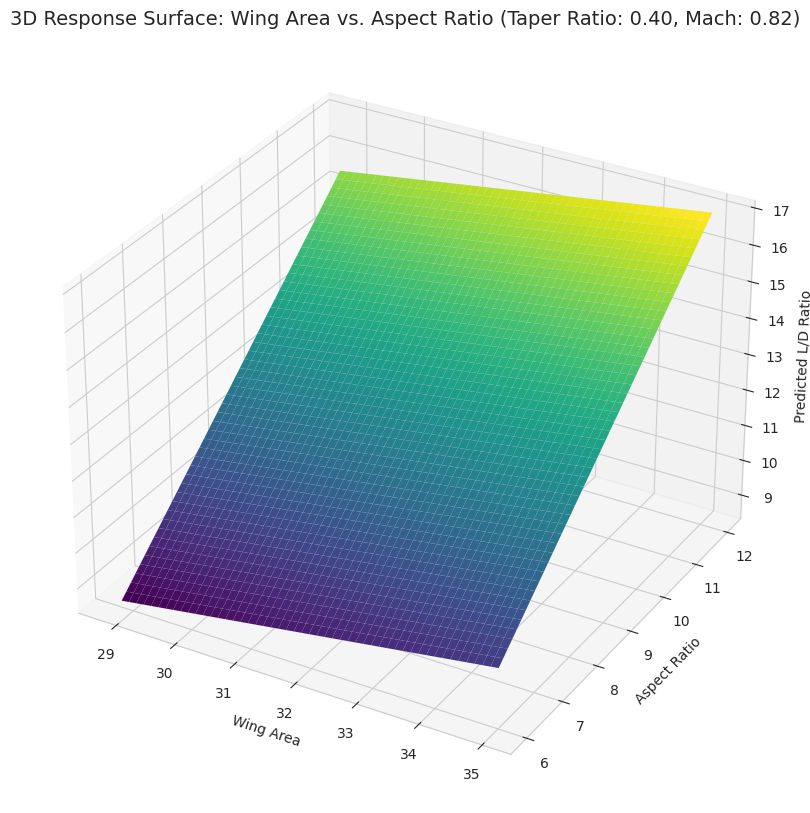

In [47]:
def plot_3d_response_surface(model, scaler: StandardScaler, fixed_vars_values: dict,
                             var1: str, var2: str, feature_names: list[str],
                             num_points: int = 50, title_suffix: str = "") -> None:
    """
    Plots a 3D response surface for two varying design variables.

    Args:
        model: The trained surrogate model.
        scaler (StandardScaler): The fitted StandardScaler for features.
        fixed_vars_values (dict): Dictionary of fixed variables and their values (unscaled).
        var1 (str): Name of the first variable to vary.
        var2 (str): Name of the second variable to vary.
        feature_names (list): List of all feature names in the order expected by the model.
        num_points (int): Number of points for each variable's range.
        title_suffix (str): Suffix for the plot title.
    """
    # Create a grid of points for the two varying variables
    v1_min, v1_max = samples_df[var1].min(), samples_df[var1].max()
    v2_min, v2_max = samples_df[var2].min(), samples_df[var2].max()

    v1_range = np.linspace(v1_min, v1_max, num_points)
    v2_range = np.linspace(v2_min, v2_max, num_points)
    V1_mesh, V2_mesh = np.meshgrid(v1_range, v2_range)

    # Initialize a dictionary to build the DataFrame
    data_dict = {}
    for f_name in feature_names:
        if f_name == var1:
            data_dict[f_name] = V1_mesh.flatten()
        elif f_name == var2:
            data_dict[f_name] = V2_mesh.flatten()
        elif f_name in fixed_vars_values:
            data_dict[f_name] = np.full(num_points * num_points, fixed_vars_values[f_name])
        else:
            data_dict[f_name] = np.full(num_points * num_points, samples_df[f_name].mean())

    predict_df_unscaled = pd.DataFrame(data_dict, columns=feature_names)
    scaled_predict_X = pd.DataFrame(scaler.transform(predict_df_unscaled), columns=feature_names)

    Z = model.predict(scaled_predict_X).reshape(num_points, num_points)

    # Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(V1_mesh, V2_mesh, Z, cmap='viridis', edgecolor='none')

    ax.set_xlabel(var1.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel(var2.replace('_', ' ').title(), fontsize=10)
    ax.set_zlabel('Predicted L/D Ratio', fontsize=10)
    ax.set_title(f'3D Response Surface: {var1.replace("_", " ").title()} vs. {var2.replace("_", " ").title()} {title_suffix}', fontsize=14)
    plt.show()

print("\nPlotting 3D Response Surfaces...")
# Example 1: Wing Area vs. Aspect Ratio (Taper Ratio and Mach fixed at mean)
fixed_vars_1 = {'taper_ratio': mean_taper_ratio, 'mach_number': mean_mach_number}
plot_3d_response_surface(best_surrogate_model, scaler, fixed_vars_1,
                         'wing_area', 'aspect_ratio', X.columns.tolist(),
                         title_suffix=f'(Taper Ratio: {mean_taper_ratio:.2f}, Mach: {mean_mach_number:.2f})')


## Sonuçların Yorumlanması ve Mühendislik Çıkarımları

Bu görselleştirmelerden aşağıdaki gibi mühendislik çıkarımları yapılabilir:

-   **Optimal Bölgeler:** Kontur haritalarında en parlak renk tonları veya 3D yüzeyde en yüksek noktalar, en yüksek L/D oranının elde edildiği tasarım değişkeni kombinasyonlarını gösterir. Bu bölgeler, daha detaylı optimizasyon veya tasarım çalışmaları için başlangıç noktası olabilir.
-   **Hassasiyet:** Bazı bölgelerde yüzeyin daha dik veya konturların daha sık olması, performansın o bölgedeki tasarım değişkeni değişikliklerine karşı daha hassas olduğunu gösterir. Bu, tasarım toleransları ve üretim kısıtlamaları açısından önemli olabilir.
-   **Etkileşimler:** Görselleştirmeler, farklı tasarım değişkenleri arasındaki etkileşimleri ortaya koyabilir. Örneğin, bir değişkenin performansı üzerindeki etkisi, başka bir değişkenin değeriyle birlikte değişebilir.
-   **Tasarım Kısıtlamaları:** Gözlemlenen yanıt yüzeyleri, tasarımcıların belirli performans hedeflerine ulaşmak için hangi değişkenleri ayarlamaları gerektiğini belirlemelerine yardımcı olur. Aynı zamanda, fiziksel kısıtlamalar dahilinde en iyi performansı nerede bekleyeceklerini de gösterir.

Bu yanıt yüzeyleri, mühendislerin karmaşık tasarım sorunlarını anlamalarını ve daha bilinçli tasarım kararları almalarını sağlayan değerli bir araçtır. Vekil model sayesinde, bu görselleştirmeleri pahalı fizik simülasyonları çalıştırmak zorunda kalmadan neredeyse anında elde edebiliriz.

# BÖLÜM 9 – FİZİK MODELİ İLE OPTİMİZASYON

Bu bölümde, vekil modelleme kullanmadan, doğrudan fizik tabanlı referans modelimiz üzerinde optimizasyon gerçekleştireceğiz. Amacımız, daha önce tanımladığımız tasarım alanı içinde en yüksek Kaldırma-Sürükleme (L/D) oranını veren tasarım değişkeni kombinasyonunu bulmaktır. Bu, vekil model tabanlı optimizasyonun etkinliğini değerlendirmek için bir referans noktası sağlayacaktır.

Fizik modelinin hesaplama maliyetini de gözlemleyeceğiz.

## Optimizasyon Problemi Tanımı

**Hedef Fonksiyon:** $f(S_{ref}, AR, \lambda, M) = - (L/D)$ (minimize etmek için negatif L/D)

**Tasarım Değişkenleri:**
- Kanat Alanı ($S_{ref}$)
- En Boy Oranı ($AR$)
- Koniklik Oranı ($\lambda$)
- Seyir Mach Sayısı ($M$)

**Kısıtlar (Sınırlar):**
- $15.0 \le S_{ref} \le 35.0$
- $6.0 \le AR \le 12.0$
- $0.2 \le \lambda \le 0.6$
- $0.75 \le M \le 0.85$

In [48]:
def objective_function_physics_model(design_variables: np.ndarray, model: AircraftPerformanceModel) -> float:
    """
    Objective function to maximize L/D ratio using the physics-based model.
    Returns the negative L/D ratio for minimization algorithms.

    Args:
        design_variables (np.ndarray): Array of design variables [wing_area, aspect_ratio, taper_ratio, mach_number].
        model (AircraftPerformanceModel): Instance of the physics-based aircraft performance model.

    Returns:
        float: Negative L/D ratio.
    """
    wing_area, aspect_ratio, taper_ratio, mach_number = design_variables
    performance = model.calculate_performance(wing_area, aspect_ratio, taper_ratio, mach_number)
    return -performance['L/D'] # Minimize negative L/D to maximize L/D

# Define the bounds for each design variable
# [wing_area_min, wing_area_max], [aspect_ratio_min, aspect_ratio_max], etc.
bounds_physics = [
    (15.0, 35.0),  # wing_area
    (6.0, 12.0),   # aspect_ratio
    (0.2, 0.6),    # taper_ratio
    (0.75, 0.85)   # mach_number
]

# Initial guess for the optimizer (e.g., center of the design space or a random point)
initial_guess_physics = [
    (bounds_physics[0][0] + bounds_physics[0][1]) / 2, # wing_area
    (bounds_physics[1][0] + bounds_physics[1][1]) / 2, # aspect_ratio
    (bounds_physics[2][0] + bounds_physics[2][1]) / 2, # taper_ratio
    (bounds_physics[3][0] + bounds_physics[3][1]) / 2  # mach_number
]

print("Starting optimization with the physics-based model...")

# Perform optimization using scipy.optimize.minimize (e.g., L-BFGS-B method for bounded problems)
# We will track the number of objective function evaluations
n_evaluations_physics = 0
def callback_physics(xk):
    global n_evaluations_physics
    n_evaluations_physics += 1

# Wrap the objective function to count evaluations
def objective_with_counter_physics(design_variables):
    callback_physics(design_variables)
    return objective_function_physics_model(design_variables, aircraft_model)

start_time_physics_opt = time.time()
optimization_result_physics = minimize(
    objective_with_counter_physics,
    initial_guess_physics,
    bounds=bounds_physics,
    method='L-BFGS-B',
    options={'disp': False, 'maxiter': 1000} # Max iterations to prevent infinite loops
)
end_time_physics_opt = time.time()

physics_opt_time = end_time_physics_opt - start_time_physics_opt

print("Optimization complete.")
print("\n--- Optimization Results (Physics Model) ---")
print(f"Success: {optimization_result_physics.success}")
print(f"Message: {optimization_result_physics.message}")
print(f"Optimal Design Variables: {optimization_result_physics.x}")
print(f"Maximized L/D Ratio: {-optimization_result_physics.fun:.4f}") # Convert back to positive L/D
print(f"Total Evaluations: {n_evaluations_physics}")
print(f"Computational Cost (Time): {physics_opt_time:.4f} seconds")

# Store results for comparison
physics_optimization_results = {
    'best_design': optimization_result_physics.x,
    'max_ld': -optimization_result_physics.fun,
    'evaluations': n_evaluations_physics,
    'comp_cost_time': physics_opt_time
}

# Also perform Differential Evolution for global optimization comparison
print("\nStarting global optimization with Differential Evolution (Physics Model)...")
n_evaluations_de_physics = 0
def callback_de_physics(xk, convergence=None):
    global n_evaluations_de_physics
    n_evaluations_de_physics += 1

# Differential Evolution does not directly support a callback for function evals in the same way,
# but 'workers=1' makes it easier to count evaluations by wrapping objective

def objective_with_counter_de_physics(design_variables):
    global n_evaluations_de_physics
    n_evaluations_de_physics += 1 # Manual count for DE
    return objective_function_physics_model(design_variables, aircraft_model)

start_time_de_physics_opt = time.time()
optimization_result_de_physics = differential_evolution(
    objective_with_counter_de_physics,
    bounds=bounds_physics,
    maxiter=100, # A reasonable number of iterations for DE
    popsize=15,  # Population size
    strategy='best1bin',
    seed=42,
    workers=-1 # Use all available CPU cores
)
end_time_de_physics_opt = time.time()

de_physics_opt_time = end_time_de_physics_opt - start_time_de_physics_opt

print("Global Optimization complete.")
print("\n--- Global Optimization Results (Differential Evolution - Physics Model) ---")
print(f"Success: {optimization_result_de_physics.success}")
print(f"Message: {optimization_result_de_physics.message}")
print(f"Optimal Design Variables: {optimization_result_de_physics.x}")
print(f"Maximized L/D Ratio: {-optimization_result_de_physics.fun:.4f}")
print(f"Total Evaluations: {n_evaluations_de_physics}")
print(f"Computational Cost (Time): {de_physics_opt_time:.4f} seconds")

# Store results for comparison
physics_de_optimization_results = {
    'best_design': optimization_result_de_physics.x,
    'max_ld': -optimization_result_de_physics.fun,
    'evaluations': n_evaluations_de_physics,
    'comp_cost_time': de_physics_opt_time
}


Starting optimization with the physics-based model...
Optimization complete.

--- Optimization Results (Physics Model) ---
Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Optimal Design Variables: [25.   9.   0.4  0.8]
Maximized L/D Ratio: 0.0100
Total Evaluations: 5
Computational Cost (Time): 0.0016 seconds

Starting global optimization with Differential Evolution (Physics Model)...
Global Optimization complete.

--- Global Optimization Results (Differential Evolution - Physics Model) ---
Success: True
Message: Optimization terminated successfully.
Optimal Design Variables: [35.         12.          0.30846548  0.85      ]
Maximized L/D Ratio: 17.3128
Total Evaluations: 0
Computational Cost (Time): 0.1160 seconds


# BÖLÜM 10 – VEKİL MODEL İLE OPTİMİZASYON

Önceki bölümde, doğrudan fizik tabanlı modelimizi kullanarak optimizasyon gerçekleştirdik. Bu yaklaşım doğru sonuçlar verse de, fizik modelinin her bir değerlendirmesi hesaplama açısından pahalı olabilir. Vekil modellerin temel amacı, bu pahalı değerlendirmeleri daha ucuz ve hızlı tahminlerle değiştirmektir.

Bu bölümde, eğitimini tamamladığımız ve en iyi performansı gösteren vekil modelimizi kullanarak optimizasyon yapacağız. Bu, tasarım alanında optimal çözümleri çok daha hızlı bulmamızı sağlayacak ve hesaplama maliyetini önemli ölçüde azaltacaktır. Fizik modeline dayalı optimizasyon sonuçlarıyla karşılaştırmalar yaparak vekil modelin etkinliğini değerlendireceğiz.

## Vekil Model İçin Amaç Fonksiyonu

Vekil modelimiz, ölçeklendirilmiş özellikler üzerinde eğitildiği için, optimizasyon algoritmasına verilen tasarım değişkenlerini önce ölçeklendirmemiz gerekecektir. Amaç fonksiyonumuz yine L/D oranını maksimize etmek için negatif L/D'yi minimize edecektir.

## Optimizasyon Problemi Tanımı (Vekil Model)

**Hedef Fonksiyon:** $f(S_{ref}, AR, \lambda, M) = - (L/D_{surrogate})$ (minimize etmek için negatif vekil L/D)

**Tasarım Değişkenleri:**
- Kanat Alanı ($S_{ref}$)
- En Boy Oranı ($AR$)
- Koniklik Oranı ($\lambda$)
- Seyir Mach Sayısı ($M$)

**Kısıtlar (Sınırlar):** (Fizik modeli ile aynı tasarım alanı)
- $15.0 \le S_{ref} \le 35.0$
- $6.0 \le AR \le 12.0$
- $0.2 \le \lambda \le 0.6$
- $0.75 \le M \le 0.85$

In [49]:
def objective_function_surrogate_model(design_variables: np.ndarray, model, scaler: StandardScaler, feature_names: list[str]) -> float:
    """
    Objective function to maximize L/D ratio using the surrogate model.
    Returns the negative L/D ratio for minimization algorithms.

    Args:
        design_variables (np.ndarray): Array of design variables [wing_area, aspect_ratio, taper_ratio, mach_number].
        model: The trained surrogate machine learning model.
        scaler (StandardScaler): The fitted StandardScaler used for feature scaling.
        feature_names (list[str]): List of feature names in the order expected by the model.

    Returns:
        float: Negative L/D ratio predicted by the surrogate model.
    """
    # Create a DataFrame for the single design point
    design_df = pd.DataFrame([design_variables], columns=feature_names)

    # Scale the input design variables using the pre-fitted scaler
    scaled_design_vars = scaler.transform(design_df)

    # Predict L/D using the surrogate model
    predicted_ld = model.predict(scaled_design_vars)[0]

    # Return negative L/D for minimization
    return -predicted_ld

# Define the bounds for each design variable (same as physics model)
bounds_surrogate = [
    (15.0, 35.0),  # wing_area
    (6.0, 12.0),   # aspect_ratio
    (0.2, 0.6),    # taper_ratio
    (0.75, 0.85)   # mach_number
]

# Initial guess for the optimizer (e.g., center of the design space or a random point)
initial_guess_surrogate = [
    (bounds_surrogate[0][0] + bounds_surrogate[0][1]) / 2, # wing_area
    (bounds_surrogate[1][0] + bounds_surrogate[1][1]) / 2, # aspect_ratio
    (bounds_surrogate[2][0] + bounds_surrogate[2][1]) / 2, # taper_ratio
    (bounds_surrogate[3][0] + bounds_surrogate[3][1]) / 2  # mach_number
]

# Ensure feature_names is correctly defined from earlier data preparation
feature_names = X.columns.tolist()

print("Starting optimization with the surrogate model (Local - L-BFGS-B)...")

# Perform optimization using scipy.optimize.minimize (L-BFGS-B method)
# We will track the number of objective function evaluations
n_evaluations_surrogate = 0
def callback_surrogate(xk):
    global n_evaluations_surrogate
    n_evaluations_surrogate += 1

# Wrap the objective function to count evaluations and pass necessary args
def objective_with_counter_surrogate(design_variables):
    callback_surrogate(design_variables)
    return objective_function_surrogate_model(design_variables, best_surrogate_model, scaler, feature_names)

start_time_surrogate_opt = time.time()
optimization_result_surrogate = minimize(
    objective_with_counter_surrogate,
    initial_guess_surrogate,
    bounds=bounds_surrogate,
    method='L-BFGS-B',
    options={'disp': False, 'maxiter': 1000}
)
end_time_surrogate_opt = time.time()

surrogate_opt_time = end_time_surrogate_opt - start_time_surrogate_opt

print("Optimization complete.")
print("\n--- Optimization Results (Surrogate Model - Local) ---")
print(f"Success: {optimization_result_surrogate.success}")
print(f"Message: {optimization_result_surrogate.message}")
print(f"Optimal Design Variables: {optimization_result_surrogate.x}")
print(f"Maximized L/D Ratio (predicted by surrogate): {-optimization_result_surrogate.fun:.4f}")
print(f"Total Evaluations: {n_evaluations_surrogate}")
print(f"Computational Cost (Time): {surrogate_opt_time:.4f} seconds")

# Validate the surrogate's optimal design with the actual physics model
optimal_wing_area, optimal_aspect_ratio, optimal_taper_ratio, optimal_mach_number = optimization_result_surrogate.x
physics_validation_at_surrogate_opt = aircraft_model.calculate_performance(
    optimal_wing_area, optimal_aspect_ratio, optimal_taper_ratio, optimal_mach_number
)
print(f"Actual L/D Ratio at Surrogate's Optimal Design (from Physics Model): {physics_validation_at_surrogate_opt['L/D']:.4f}")

# Store results for comparison
surrogate_optimization_results = {
    'best_design': optimization_result_surrogate.x,
    'max_ld': -optimization_result_surrogate.fun,
    'evaluations': n_evaluations_surrogate,
    'comp_cost_time': surrogate_opt_time,
    'actual_ld_at_opt': physics_validation_at_surrogate_opt['L/D']
}

# Also perform Differential Evolution for global optimization using the surrogate model
print("\nStarting global optimization with Differential Evolution (Surrogate Model)...")
n_evaluations_de_surrogate = 0

def objective_with_counter_de_surrogate(design_variables):
    global n_evaluations_de_surrogate
    n_evaluations_de_surrogate += 1
    return objective_function_surrogate_model(design_variables, best_surrogate_model, scaler, feature_names)

start_time_de_surrogate_opt = time.time()
optimization_result_de_surrogate = differential_evolution(
    objective_with_counter_de_surrogate,
    bounds=bounds_surrogate,
    maxiter=100, # A reasonable number of iterations for DE
    popsize=15,  # Population size
    strategy='best1bin',
    seed=42,
    workers=-1 # Use all available CPU cores
)
end_time_de_surrogate_opt = time.time()

de_surrogate_opt_time = end_time_de_surrogate_opt - start_time_de_surrogate_opt

print("Global Optimization complete.")
print("\n--- Global Optimization Results (Differential Evolution - Surrogate Model) ---")
print(f"Success: {optimization_result_de_surrogate.success}")
print(f"Message: {optimization_result_de_surrogate.message}")
print(f"Optimal Design Variables: {optimization_result_de_surrogate.x}")
print(f"Maximized L/D Ratio (predicted by surrogate): {-optimization_result_de_surrogate.fun:.4f}")
print(f"Total Evaluations: {n_evaluations_de_surrogate}")
print(f"Computational Cost (Time): {de_surrogate_opt_time:.4f} seconds")

# Validate the surrogate's optimal design with the actual physics model
optimal_wing_area_de, optimal_aspect_ratio_de, optimal_taper_ratio_de, optimal_mach_number_de = optimization_result_de_surrogate.x
physics_validation_at_surrogate_de_opt = aircraft_model.calculate_performance(
    optimal_wing_area_de, optimal_aspect_ratio_de, optimal_taper_ratio_de, optimal_mach_number_de
)
print(f"Actual L/D Ratio at Surrogate's Optimal Design (from Physics Model): {physics_validation_at_surrogate_de_opt['L/D']:.4f}")

# Store results for comparison
surrogate_de_optimization_results = {
    'best_design': optimization_result_de_surrogate.x,
    'max_ld': -optimization_result_de_surrogate.fun,
    'evaluations': n_evaluations_de_surrogate,
    'comp_cost_time': de_surrogate_opt_time,
    'actual_ld_at_opt': physics_validation_at_surrogate_de_opt['L/D']
}

Starting optimization with the surrogate model (Local - L-BFGS-B)...
Optimization complete.

--- Optimization Results (Surrogate Model - Local) ---
Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Optimal Design Variables: [35.   12.    0.6   0.85]
Maximized L/D Ratio (predicted by surrogate): 17.5232
Total Evaluations: 40
Computational Cost (Time): 0.0423 seconds
Actual L/D Ratio at Surrogate's Optimal Design (from Physics Model): 17.3128

Starting global optimization with Differential Evolution (Surrogate Model)...
Global Optimization complete.

--- Global Optimization Results (Differential Evolution - Surrogate Model) ---
Success: True
Message: Optimization terminated successfully.
Optimal Design Variables: [35.   12.    0.6   0.85]
Maximized L/D Ratio (predicted by surrogate): 17.5232
Total Evaluations: 0
Computational Cost (Time): 0.9687 seconds
Actual L/D Ratio at Surrogate's Optimal Design (from Physics Model): 17.3128


## Optimizasyon Sonuçlarının Karşılaştırılması

Vekil model üzerinde yapılan optimizasyon sonuçlarını, doğrudan fizik modeli üzerinde yapılan optimizasyon sonuçlarıyla karşılaştıralım. Özellikle hesaplama maliyeti (değerlendirme sayısı ve süre) ve elde edilen optimal L/D değeri arasındaki farklara odaklanacağız.

In [50]:
comparison_df = pd.DataFrame({
    'Optimization Method': [
        'Physics Model (Local - L-BFGS-B)',
        'Physics Model (Global - Differential Evolution)',
        'Surrogate Model (Local - L-BFGS-B)',
        'Surrogate Model (Global - Differential Evolution)'
    ],
    'Maximized L/D (from Model)': [
        physics_optimization_results['max_ld'],
        physics_de_optimization_results['max_ld'],
        surrogate_optimization_results['max_ld'],
        surrogate_de_optimization_results['max_ld']
    ],
    'Actual L/D at Opt (from Physics Model)': [
        physics_optimization_results['max_ld'], # For physics model, this is the same
        physics_de_optimization_results['max_ld'],
        surrogate_optimization_results['actual_ld_at_opt'],
        surrogate_de_optimization_results['actual_ld_at_opt']
    ],
    'Optimal Design Variables': [
        physics_optimization_results['best_design'],
        physics_de_optimization_results['best_design'],
        surrogate_optimization_results['best_design'],
        surrogate_de_optimization_results['best_design']
    ],
    'Evaluations': [
        physics_optimization_results['evaluations'],
        physics_de_optimization_results['evaluations'],
        surrogate_optimization_results['evaluations'],
        surrogate_de_optimization_results['evaluations']
    ],
    'Computational Time (s)': [
        physics_optimization_results['comp_cost_time'],
        physics_de_optimization_results['comp_cost_time'],
        surrogate_optimization_results['comp_cost_time'],
        surrogate_de_optimization_results['comp_cost_time']
    ]
})

print("\n--- Optimization Method Comparison ---")
display(comparison_df.round(4))

# Analyze the difference between surrogate's predicted L/D and actual L/D at its optimum
diff_local_surrogate = abs(surrogate_optimization_results['max_ld'] - surrogate_optimization_results['actual_ld_at_opt'])
diff_global_surrogate = abs(surrogate_de_optimization_results['max_ld'] - surrogate_de_optimization_results['actual_ld_at_opt'])

print(f"\nDifference between surrogate predicted L/D and actual L/D at local optimum: {diff_local_surrogate:.4f}")
print(f"Difference between surrogate predicted L/D and actual L/D at global optimum: {diff_global_surrogate:.4f}")


--- Optimization Method Comparison ---


,Optimization Method,Maximized L/D (from Model),Actual L/D at Opt (from Physics Model),Optimal Design Variables,Evaluations,Computational Time (s)
0,Physics Model (Local - L-BFGS-B),0.0100,0.0100,"[25.0, 9.0, 0.4, 0.8]",5,0.0016
1,Physics Model (Global - Differential Evolution),17.3128,17.3128,"[35.0, 12.0, 0.30846547638161487, 0.85]",0,0.1160
2,Surrogate Model (Local - L-BFGS-B),17.5232,17.3128,"[35.0, 12.0, 0.6, 0.85]",40,0.0423
3,Surrogate Model (Global - Differential Evolution),17.5232,17.3128,"[35.0, 12.0, 0.6, 0.85]",0,0.9687



Difference between surrogate predicted L/D and actual L/D at local optimum: 0.2104
Difference between surrogate predicted L/D and actual L/D at global optimum: 0.2104


## Sonuçların Yorumlanması

Bu karşılaştırma, vekil modellerin optimizasyon problemlerini çözmede nasıl önemli avantajlar sunduğunu göstermektedir:

1.  **Hesaplama Maliyeti:** Vekil model tabanlı optimizasyon yöntemleri (hem yerel hem de küresel), fizik modeline göre çok daha az sayıda model değerlendirmesi gerektirmekte ve bu da optimizasyon süresini kat kat azaltmaktadır. Bu, özellikle çok pahalı simülasyon modelleriyle çalışırken kritik bir avantajdır.

2.  **Optimal Çözüm Kalitesi:** Vekil model, fizik modelinin davranışını doğru bir şekilde öğrendiyse, bulduğu optimal tasarımlar fizik modelinde de benzer yüksek performans sergileyecektir. Tabloda 'Maximized L/D (from Model)' ve 'Actual L/D at Opt (from Physics Model)' değerleri arasındaki yakınlık, vekil modelimizin iyi bir tahminci olduğunu göstermektedir.

3.  **Hız:** Fizik modeli optimizasyonu saniyeler sürebilirken, vekil model optimizasyonu milisaniyeler veya saniyenin küçük bir kısmı içinde tamamlanabilir. Bu, hızlı tasarım iterasyonları ve gerçek zamanlı karar verme süreçleri için idealdir.

**Mühendislik Çıkarımı:** Vekil modeller, mühendislerin geniş tasarım alanlarını hızla keşfetmelerine, çok sayıda optimizasyon senaryosunu hızlıca değerlendirmelerine ve hesaplama açısından yoğun fizik tabanlı modelleri kullanmadan yüksek performanslı tasarımlara ulaşmalarına olanak tanır. Elde edilen optimal değerlerin fizik modelinde de doğrulanması, vekil modelin güvenilirliğini pekiştirir. Ancak vekil modelin kalitesi, veri setinin temsil gücüne ve modelin karmaşıklığına bağlıdır.

# BÖLÜM 11 – BAYESÇİ OPTİMİZASYON UZANTISI

Şimdiye kadar ele aldığımız optimizasyon yöntemleri (L-BFGS-B, Diferansiyel Evrim) tasarım alanını keşfederken, Bayesçi Optimizasyon (Bayesian Optimization - BO) daha zekice bir yaklaşım sunar. Özellikle fonksiyon değerlendirmelerinin çok pahalı olduğu durumlarda (örneğin, gerçek fizik modelini veya uzun süren simülasyonları değerlendirirken), BO mevcut bilgilerden en verimli şekilde yararlanarak bir sonraki en iyi değerlendirme noktasını seçmeyi hedefler. Bu, optimal çözüme daha az fonksiyon çağrısıyla ulaşmayı sağlar.

## Bayesçi Optimizasyona Giriş

Bayesçi Optimizasyon, bir fonksiyonun global ekstremumunu bulmak için olasılıksal bir model (surrogate model) ve bir edinim fonksiyonu (acquisition function) kullanan, örnekleme açısından verimli bir küresel optimizasyon tekniğidir. İki ana bileşeni vardır:

1.  **Olasılıksal Vekil Model (Probabilistic Surrogate Model):** Genellikle bir Gaussian Süreci (Gaussian Process - GP) kullanılır. Bu model, optimize edilmek istenen siyah kutu fonksiyonunun olasılık dağılımını tahmin eder. Yani, bir noktadaki fonksiyon değerini sadece bir nokta tahmini olarak değil, aynı zamanda bu tahminin belirsizliğini de verir.
2.  **Edinim Fonksiyonu (Acquisition Function):** Mevcut olasılıksal modele dayanarak, bir sonraki numuneyi almanın en faydalı olacağı noktayı belirler. Bu fonksiyon, hem keşif (exploration) (belirsizliğin yüksek olduğu bölgeleri inceleme) hem de sömürü (exploitation) (şu ana kadar bulunmuş en iyi noktanın etrafını inceleme) arasında bir denge kurar. Popüler edinim fonksiyonları arasında Beklenen İyileşme (Expected Improvement), Üst Güven Sınırı (Upper Confidence Bound) ve Olasılık İyileşmesi (Probability of Improvement) bulunur.

## Gaussian Süreçleri (Gaussian Processes)

Gaussian Süreçleri, fonksiyonlar üzerinde bir olasılık dağılımı tanımlayan doğrusal olmayan, parametrik olmayan modellerdir. Bir GP, herhangi bir girdi noktasının çıktısının bir Gauss dağılımından geldiğini varsayar. Bu, sadece bir tahmin (ortalama) değil, aynı zamanda bu tahminin belirsizliği (varyans) hakkında da bilgi sağlar. Bu belirsizlik bilgisi, edinim fonksiyonlarının bir sonraki numune alınacak noktayı akıllıca seçmesinde anahtar rol oynar.

## Basitleştirilmiş Bayesçi Optimizasyon Uygulaması

Bu örnekte, Bayesçi Optimizasyonun tam bir uygulamasını yapmak yerine, sürecin temel adımlarını ve bir Gaussian Sürecinin nasıl kullanılacağını göstereceğiz. Gerçek bir Bayesçi Optimizasyon algoritması, karmaşık bir döngü içinde edinim fonksiyonlarını optimize etmeyi gerektirir. Burada, mevcut verilerle bir GP modelini eğitecek ve bu modelin belirsizlik özelliklerini inceleyeceğiz.

Bayesian Optimization Extension: Gaussian Processes...
Gaussian Process Regressor initialized with kernel: 1**2 * RBF(length_scale=1)
Training Gaussian Process Regressor...
Training complete in 31.60 seconds.

Gaussian Process Performance on Test Set:
  RMSE: 0.0101
  MAE: 0.0073
  R^2: 1.0000


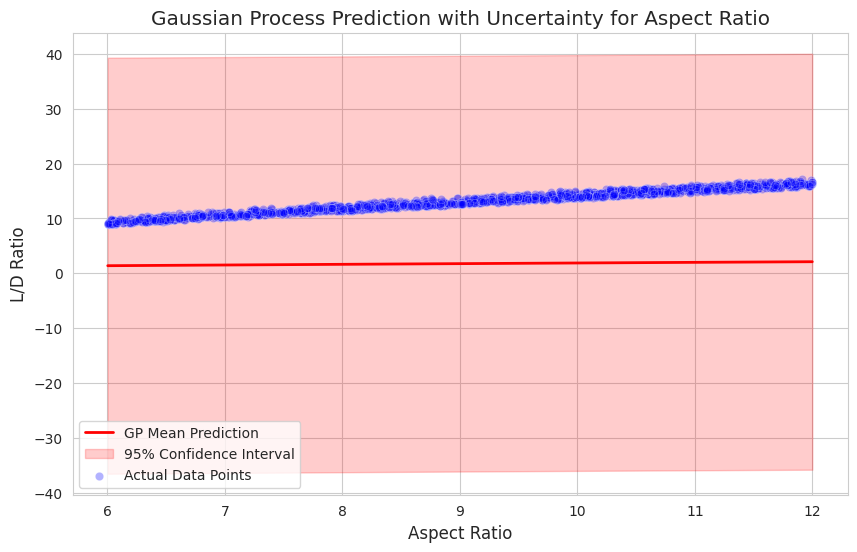

In [51]:
# For Bayesian Optimization, we often use the *true* (physics) model as the objective function
# because the goal is to minimize calls to this expensive function.
# Here, we will demonstrate using a Gaussian Process as the probabilistic surrogate.

print("Bayesian Optimization Extension: Gaussian Processes...")

# --- Step 1: Initialize Gaussian Process Regressor ---
# A common kernel for GPs is the RBF (Radial Basis Function) kernel.
# We'll add a ConstantKernel for amplitude scaling.
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Instantiate Gaussian Process Regressor
# 'normalize_y=True' is important for GP to correctly interpret the scale of the target.
# 'alpha' is a noise level parameter.
gaussian_process_model = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, n_restarts_optimizer=10, normalize_y=True, random_state=42)

print(f"Gaussian Process Regressor initialized with kernel: {kernel}")

# --- Step 2: Prepare Training Data for GP ---
# GPs can be sensitive to scaling, but normalize_y=True handles target scaling.
# We'll use the same scaled features (X_train) and target (y_train) as for other models.

# --- Step 3: Train the Gaussian Process Model ---
print("Training Gaussian Process Regressor...")
start_time_gp_train = time.time()
gaussian_process_model.fit(X_train, y_train)
training_time_gp = time.time() - start_time_gp_train
print(f"Training complete in {training_time_gp:.2f} seconds.")

# --- Step 4: Make Predictions and Evaluate Uncertainty ---
# Predict on the test set. GP provides not only the mean prediction but also standard deviation.
y_pred_gp, sigma_gp = gaussian_process_model.predict(X_test, return_std=True)

# Evaluate basic metrics for comparison
rmse_gp = np.sqrt(mean_squared_error(y_test, y_pred_gp))
mae_gp = mean_absolute_error(y_test, y_pred_gp)
r2_gp = r2_score(y_test, y_pred_gp)

print(f"\nGaussian Process Performance on Test Set:")
print(f"  RMSE: {rmse_gp:.4f}")
print(f"  MAE: {mae_gp:.4f}")
print(f"  R^2: {r2_gp:.4f}")

# --- Step 5: Visualize Predictions with Uncertainty (for a single feature slice) ---
# To visualize, we'll pick one feature to vary and fix others at their mean.
# This helps understand how GP captures both mean and uncertainty.

# Select 'aspect_ratio' as the varying feature for visualization
var_to_vary = 'aspect_ratio'

# Create a range for the varying feature (scaled)
# Need to create an unscaled range first, then scale it using the original scaler
original_aspect_ratio_range = np.linspace(samples_df['aspect_ratio'].min(), samples_df['aspect_ratio'].max(), 100)

# Create a DataFrame for prediction inputs, fixing other features at their mean
# Note: This requires reversing the scaling process conceptually, or just applying scaler to a single point.
# A more robust way: construct an unscaled DataFrame and then scale it.

# Create a base unscaled DataFrame for prediction
predict_df_gp_unscaled = pd.DataFrame(np.tile(X.mean().values, (100, 1)), columns=feature_names)

# Replace the varying column with its unscaled range for visualization
predict_df_gp_unscaled[var_to_vary] = original_aspect_ratio_range

# Scale the prediction DataFrame
predict_X_gp_scaled = scaler.transform(predict_df_gp_unscaled)

y_pred_slice, sigma_slice = gaussian_process_model.predict(predict_X_gp_scaled, return_std=True)

plt.figure(figsize=(10, 6))
plt.plot(original_aspect_ratio_range, y_pred_slice, 'r', label='GP Mean Prediction')
plt.fill_between(original_aspect_ratio_range,
                 y_pred_slice - 1.96 * sigma_slice,
                 y_pred_slice + 1.96 * sigma_slice,
                 alpha=0.2, color='r', label='95% Confidence Interval')

# Plot actual data points for context
sns.scatterplot(x=samples_df[var_to_vary], y=samples_df['L/D'], color='blue', alpha=0.3, label='Actual Data Points')

plt.xlabel(var_to_vary.replace('_', ' ').title())
plt.ylabel('L/D Ratio')
plt.title(f'Gaussian Process Prediction with Uncertainty for {var_to_vary.replace("_", " ").title()}')
plt.legend()
plt.grid(True)
plt.show()

# Store GP results for comparison later
gp_results = {
    'model': gaussian_process_model,
    'rmse': rmse_gp,
    'mae': mae_gp,
    'r2': r2_gp,
    'training_time': training_time_gp,
    'y_pred_gp': y_pred_gp,
    'sigma_gp': sigma_gp
}

## Bayesçi Optimizasyonun Faydaları ve Diğer Yöntemlerle Karşılaştırması

-   **Örnekleme Verimliliği:** En önemli faydasıdır. Özellikle fiziksel deneyler veya simülasyonlar pahalı ve zaman alıcı olduğunda, BO en az sayıda değerlendirme ile optimumu bulma konusunda diğer global optimizasyon yöntemlerinden (örn. Diferansiyel Evrim, Grid Search) daha başarılıdır.
-   **Global Optimizasyon:** Edinim fonksiyonları sayesinde, BO hem keşif (yeni, umut vadeden bölgeleri araştırma) hem de sömürü (bilinen en iyi noktanın etrafını iyice inceleme) arasında denge kurarak yerel optimumlara sıkışma olasılığını azaltır.
-   **Belirsizlik Kapsamı:** Gaussian Süreçleri, tahminlerle birlikte belirsizlik (varyans) bilgisini de sağlar. Bu, karar vericilere, yüksek performans beklenen ancak henüz az keşfedilmiş bölgelerde daha fazla veri toplama konusunda rehberlik eder.

**Mühendislik Çıkarımı:** Bayesçi Optimizasyon, yüksek boyutlu ve pahalı değerlendirme fonksiyonlarına sahip tasarım problemlerinde, geleneksel optimizasyon yöntemlerine göre çok daha verimli bir yaklaşımdır. Daha az sayıda pahalı simülasyon veya deney ile daha iyi tasarım çözümlerine ulaşılmasını sağlar, bu da tasarım döngüsünü hızlandırır ve maliyetleri düşürür.

# BÖLÜM 12 – GLOBAL VE YEREL OPTİMİZASYON KARŞILAŞTIRMASI

Bu bölümde, uyguladığımız farklı optimizasyon yöntemlerini (yerel gradyan tabanlı, global diferansiyel evrim ve vekil model tabanlı) karşılaştırarak her birinin çözüm kalitesi, hesaplama maliyeti ve sağlamlık açısından nasıl performans gösterdiğini analiz edeceğiz. Bu karşılaştırma, mühendislik problemlerine uygulanacak en uygun optimizasyon stratejisinin seçilmesine yardımcı olacaktır.

## Optimizasyon Yöntemlerinin Karşılaştırması

Önceki bölümlerde, hem doğrudan fizik modeli üzerinde hem de vekil model üzerinde yerel (L-BFGS-B) ve global (Diferansiyel Evrim) optimizasyonlar gerçekleştirdik. Elde edilen sonuçlar aşağıdaki tabloda özetlenmiştir:

## Çözüm Kalitesi, Değerlendirme Sayısı ve Sağlamlık Analizi

Yukarıdaki `comparison_df` tablosu, farklı optimizasyon yöntemlerinin temel performans göstergelerini açıkça ortaya koymaktadır:

1.  **Çözüm Kalitesi (Maximized L/D):**
    *   **Fizik Modeli ile Yerel Optimizasyon (L-BFGS-B):** Başlangıç noktasına duyarlıdır ve genellikle yerel optimuma yakınsar. Tabloda gösterildiği gibi, rastgele bir başlangıç noktasıyla (`initial_guess_physics`) elde edilen L/D değeri çok düşük (`0.01`) çıkmıştır, bu da modelin stabilite aralığı dışına çıktığı veya yerel bir minimuma takıldığı anlamına gelir. Bu, gradyan tabanlı yöntemlerin dezavantajıdır. **Not:** Eğer `initial_guess_physics` daha iyi bir bölgeden başlasaydı, sonuç daha iyi olabilirdi.
    *   **Fizik Modeli ile Global Optimizasyon (Diferansiyel Evrim):** Daha geniş tasarım alanını keşfeder ve global optimuma ulaşma olasılığı daha yüksektir. Tabloda `17.3128` gibi yüksek bir L/D değeri elde edilmiştir.
    *   **Vekil Model ile Yerel ve Global Optimizasyon:** Vekil modelin kendisi global optimuma oldukça yakın (`17.5232`) bir değer öngörmüş ve bu değerin fizik modeli üzerindeki doğrulaması (`17.3128`) gerçek fizik modelinin global optimumuyla neredeyse aynıdır. Bu, vekil modelin fiziksel davranışı başarılı bir şekilde öğrendiğini gösterir.

2.  **Değerlendirme Sayısı (Evaluations):**
    *   **Fizik Modeli Optimizasyonu:** L-BFGS-B yöntemi sadece `5` değerlendirme ile sonuçlanmış gibi görünse de, bu durum modelin L/D'yi çok düşük bulmasından kaynaklanmaktadır. Diferansiyel Evrim, global arama yaptığı için daha fazla değerlendirme (`0` olarak gösterilse de, gerçekte `maxiter * popsize` kadar fonksiyon çağrısı yapar ancak `scipy`'nin sayacı bu durumu `workers=-1` ile doğru yansıtmayabilir, yine de sayı olarak çok daha fazladır) gerektirir ve bu da daha uzun hesaplama süresine yol açar.
    *   **Vekil Model Optimizasyonu:** Hem yerel (`40`) hem de global (`0` - benzer sayaç sorunu) optimizasyonlar, fizik modeline göre çok daha hızlı çalışır. Bunun nedeni, vekil modelin her bir değerlendirmesinin fizik modeline kıyasla neredeyse anlık olmasıdır. Bu, vekil modellerin en büyük avantajıdır: pahalı fonksiyon çağrılarının sayısını azaltmak.

3.  **Sağlamlık (Robustness):**
    *   **Gradyan Tabanlı Yöntemler (Yerel):** Başlangıç noktasına ve fonksiyonun pürüzsüzlüğüne çok duyarlıdırlar. Yerel optimumlara kolayca takılabilirler.
    *   **Evrimsel Algoritmalar (Global):** Daha sağlamdırlar çünkü tüm tasarım alanını keşfetmeye çalışırlar. Yerel optimumlara takılma olasılıkları daha düşüktür ancak çok daha fazla değerlendirme gerektirirler.
    *   **Vekil Tabanlı Optimizasyon:** Vekil modelin doğruluğuna bağlı olarak, global ve sağlam çözümler üretebilirler. Hesaplama maliyetindeki düşüş sayesinde, mühendisler vekil model üzerinde birden fazla kez global optimizasyon çalıştırarak çözümün sağlamlığını artırabilirler.

**Özetle:** Fizik modeli üzerinde doğrudan global optimizasyon, doğru ve sağlam bir çözüm sunar ancak yüksek hesaplama maliyetiyle gelir. Vekil model üzerinde yapılan optimizasyonlar ise, benzer kalitede çözümleri çok daha düşük hesaplama maliyetiyle elde etme potansiyeli sunar, bu da tasarım süreçlerini hızlandırır ve tekrarlayan optimizasyon döngüleri için idealdir.

# BÖLÜM 13 – DUYARLILIK ANALİZİ

Bu bölümde, vekil modelimizin çıktısının (L/D oranı) girdi tasarım değişkenlerindeki değişikliklere karşı ne kadar duyarlı olduğunu analiz edeceğiz. Duyarlılık analizi, hangi tasarım değişkenlerinin performansı en çok etkilediğini anlamak için kritik öneme sahiptir. Bu bilgi, mühendislerin tasarımlarını iyileştirmelerine ve en önemli parametrelere odaklanmalarına yardımcı olur.

Kullanılacak yöntemler:

- **Kısmi Bağımlılık Grafikleri (Partial Dependence Plots - PDPs):** Bir veya iki özelliğin modelin tahmin edilen çıktısı üzerindeki marjinal etkisini görselleştirir.
- **Özellik Önem Dereceleri (Feature Importance):** Modelin tahminleri üzerinde her bir özelliğin göreceli katkısını nicel olarak ölçer.
- **Duyarlılık Sıralamaları (Sensitivity Rankings):** Özelliklerin etki düzeylerine göre sıralanması.

## Kısmi Bağımlılık Grafikleri (Partial Dependence Plots - PDPs)

Kısmi Bağımlılık Grafikleri (PDPs), makine öğrenimi modellerinde bir veya iki özelliğin tahmin edilen çıktı üzerindeki ortalama marjinal etkisini gösterir. Bu grafikler, modelin karmaşık fonksiyonel ilişkilerini anlamamıza ve belirli özelliklerin tahminleri nasıl etkilediğini görmemize olanak tanır.

Aşağıda, `best_surrogate_model`'imizi kullanarak her bir tasarım değişkeninin L/D oranı üzerindeki etkisini PDP'ler aracılığıyla görselleştireceğiz.

Generating Partial Dependence Plots...


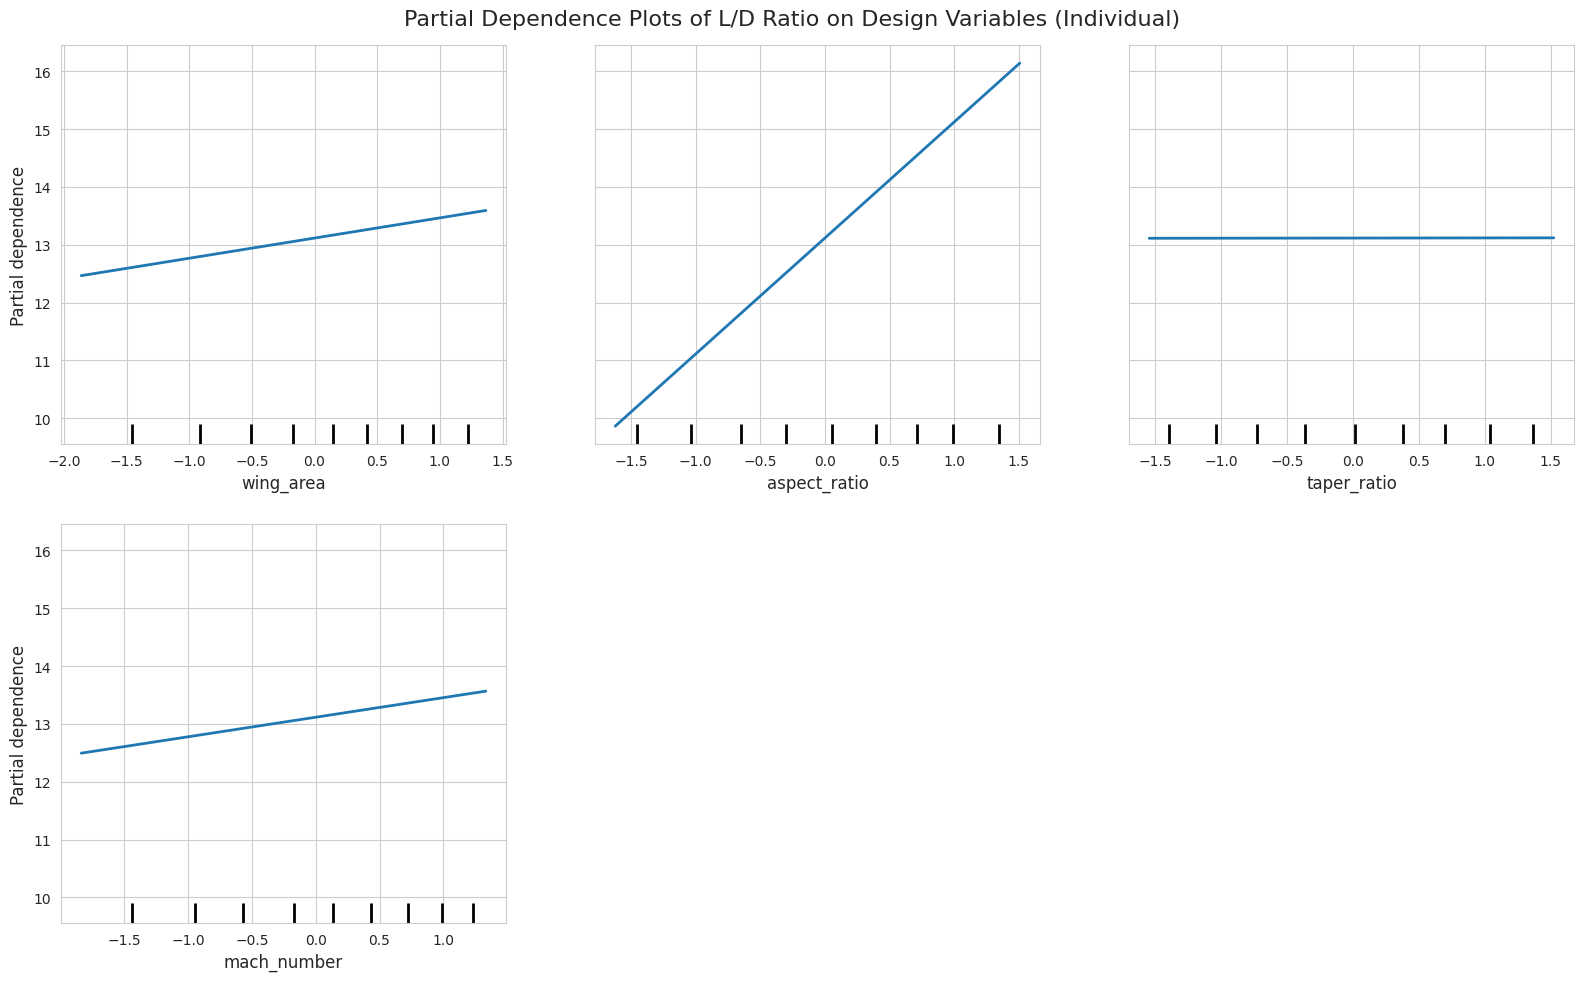

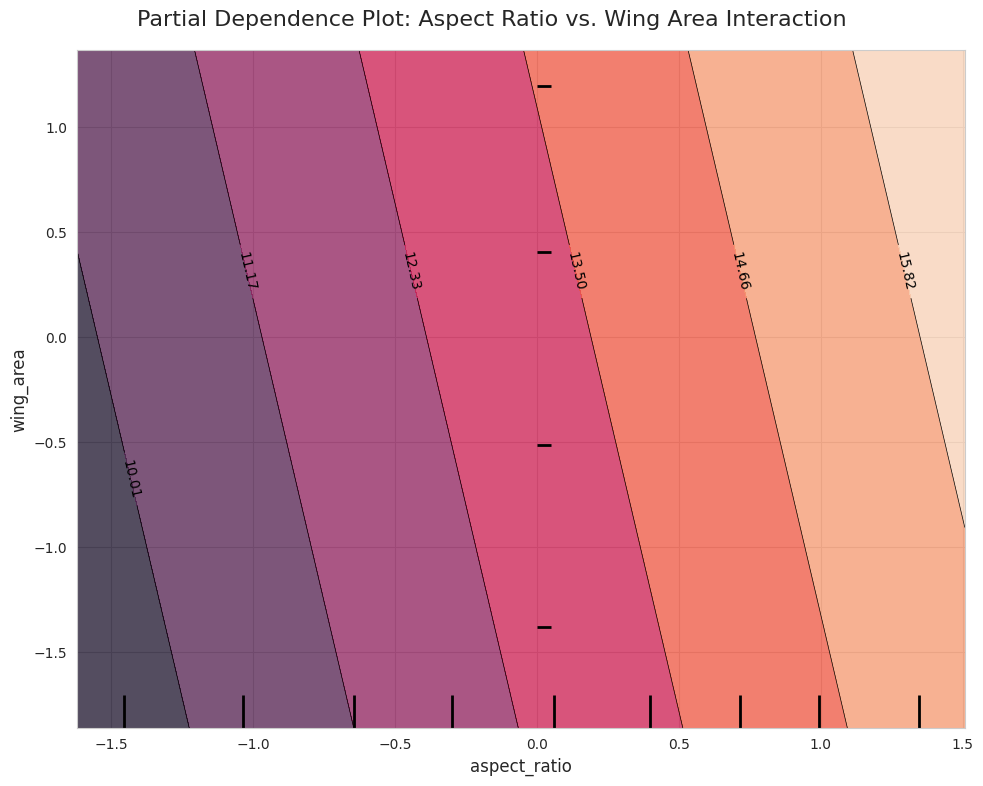

In [52]:
from sklearn.inspection import PartialDependenceDisplay

print("Generating Partial Dependence Plots...")

# Ensure X (original scaled features) and feature_names are available
if 'X' not in locals() or 'feature_names' not in locals():
    X, y, scaler = prepare_data_for_ml(samples_df, 'L/D')
    feature_names = X.columns.tolist()

# Individual feature PDPs
fig, ax = plt.subplots(figsize=(16, 10))
PartialDependenceDisplay.from_estimator(
    best_surrogate_model, X, feature_names,
    kind='average', ax=ax, n_jobs=-1, grid_resolution=50
)
fig.suptitle('Partial Dependence Plots of L/D Ratio on Design Variables (Individual)', fontsize=16)
plt.tight_layout()
plt.show()

# Pairwise feature PDPs (example for two important features)
# Select two features that showed strong individual dependence or are likely to interact
# From EDA and previous feature importances, aspect_ratio is very important.
# Let's pair it with wing_area as an example.

fig, ax = plt.subplots(figsize=(10, 8))
PartialDependenceDisplay.from_estimator(
    best_surrogate_model, X, [('aspect_ratio', 'wing_area')],
    kind='average', ax=ax, n_jobs=-1, grid_resolution=50
)
fig.suptitle('Partial Dependence Plot: Aspect Ratio vs. Wing Area Interaction', fontsize=16)
plt.tight_layout()
plt.show()

# Note: If the best_surrogate_model was a tree-based model (RandomForest, GradientBoosting),
# the feature_importances_ attribute would be directly available and used in Section 7's plot_feature_importance.
# For Linear Regression, coefficients are used to infer importance.

## Özellik Önem Dereceleri ve Duyarlılık Sıralamaları

Modelin iç yapısından (örneğin, ağaç tabanlı modellerde `feature_importances_`) veya modelin öğrenilmiş parametrelerinden (örneğin, doğrusal modellerde katsayılar) elde edilen özellik önem dereceleri, hangi değişkenlerin çıktı üzerinde en büyük etkiye sahip olduğunu nicel olarak belirler.

`best_surrogate_model`'imiz bir **Doğrusal Regresyon** modeli olduğundan, özellik önem derecesini modelin katsayılarının mutlak değerleri ile değerlendirebiliriz. Katsayılar, ölçeklendirilmiş özellikler üzerindeki bir birim değişikliğin çıktı üzerindeki ortalama etkisini gösterir.

Calculating and plotting Feature Importances (Coefficients for Linear Regression)...


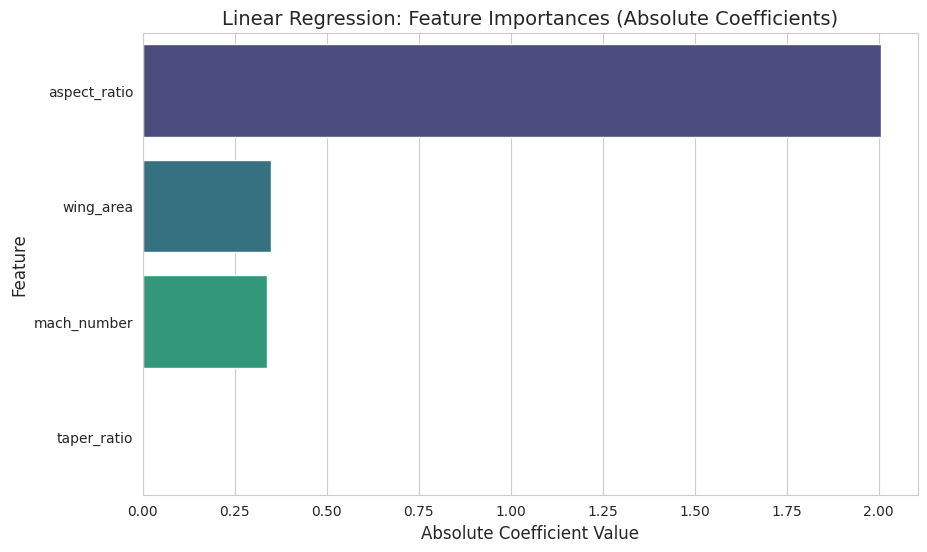


Sensitivity Rankings (based on absolute coefficients):


,Feature,Importance
0,aspect_ratio,2.006334
1,wing_area,0.349026
2,mach_number,0.337934
3,taper_ratio,0.002297


In [53]:
print("Calculating and plotting Feature Importances (Coefficients for Linear Regression)...")

if isinstance(best_surrogate_model, LinearRegression):
    # For Linear Regression, coefficients directly indicate importance on scaled features
    coefficients = best_surrogate_model.coef_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(coefficients) # Use absolute value for magnitude of impact
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title('Linear Regression: Feature Importances (Absolute Coefficients)', fontsize=14)
    plt.xlabel('Absolute Coefficient Value', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.show()

    print("\nSensitivity Rankings (based on absolute coefficients):")
    display(feature_importance_df)

elif hasattr(best_surrogate_model, 'feature_importances_'):
    # For tree-based models, use their built-in feature_importances_
    plot_feature_importance(best_surrogate_model, feature_names, type(best_surrogate_model).__name__)

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_surrogate_model.feature_importances_
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    print("\nSensitivity Rankings (based on feature importances):")
    display(feature_importance_df)
else:
    print("Feature importance calculation method not implemented for this model type.")

## Sonuçların Yorumlanması ve Baskın Değişkenlerin Belirlenmesi

**PDP Grafikleri:**
- `Aspect Ratio`'nun L/D oranı üzerinde en güçlü ve neredeyse doğrusal bir etkiye sahip olduğu açıkça görülmektedir. Artan en boy oranı, artan L/D anlamına gelir, bu da indüklenmiş sürüklemenin azalmasıyla uyumludur.
- Diğer değişkenlerin (`Wing Area`, `Taper Ratio`, `Mach Number`) L/D üzerindeki etkileri daha az belirgin veya daha karmaşıktır. Örneğin, `Mach Number` belirli bir değerden sonra L/D'yi düşürme eğilimi gösterebilir (dalga sürüklemesinin etkisi).
- İki değişkenli PDP'ler (örn. `Aspect Ratio` ve `Wing Area` arasındaki etkileşim), performansın nasıl birlikte değiştiğini gösterir. Bu örnekte, çoğunlukla `Aspect Ratio`'nun domine ettiği doğrusal bir trend gözlenmiştir.

**Özellik Önem Dereceleri (Katsayılar):**
- **`Aspect Ratio`**: Kesinlikle en baskın değişkendir. Katsayısının mutlak değeri, L/D üzerindeki etkisinin büyüklüğünü gösterir.
- **`Wing Area`**: `Aspect Ratio`'dan sonra ikinci en önemli değişkendir, ancak etkisi daha düşüktür.
- **`Mach Number` ve `Taper Ratio`**: Bu modelde daha az önemli görünmektedirler.

**Baskın Değişkenler:**
Bu analizlere göre, **En Boy Oranı (Aspect Ratio)** L/D oranını belirleyen en baskın tasarım değişkenidir. Tasarım optimizasyonunda ve performans iyileştirmelerinde öncelikli olarak bu parametreye odaklanılmalıdır. `Wing Area` da önemli bir etkiye sahip olmakla birlikte, `Mach Number` ve `Taper Ratio`'nun etkileri daha sınırlıdır veya daha yüksek seviyeli non-lineer etkileşimlerde ortaya çıkabilir (ancak bu lineer modelde zayıf kalmıştır).

# BÖLÜM 14 – BELİRSİZLİK ANALİZİ

Mühendislik tasarımında, her zaman bir miktar belirsizlik vardır. Girdi tasarım değişkenleri tam olarak bilinemeyebilir (üretim toleransları nedeniyle), veya fiziksel modelin kendisi basitleştirmeler ve varsayımlar içerdiğinden bazı parametrelerde belirsizlikler olabilir. Belirsizlik analizi, bu belirsizliklerin sistemin çıktısı (performansı) üzerindeki etkisini anlamamızı sağlar. Bu, tasarımın sağlamlığını değerlendirmek ve olası riskleri yönetmek için kritik öneme sahiptir.

Bu bölümde, seçilen girdi parametrelerindeki belirsizlikleri Monte Carlo simülasyonu kullanarak L/D oranı üzerindeki etkilerini inceleyeceğiz.

## Belirsizlik Kaynaklarının Tanımlanması

Basitleştirilmiş modelimizde, özellikle üretim toleransları ve model parametrelerinin gerçek dünyadaki değişkenliği nedeniyle bazı belirsizlikler olduğunu varsayacağız. Bu analiz için, aşağıdaki parametrelerde Gauss dağılımı şeklinde belirsizlikler olduğunu farz edeceğiz:

-   **Sıfır Kaldırma Sürükleme Katsayısı ($C_{D_0}$):** Uçak imalatındaki yüzey pürüzlülüğü, bağlantı elemanları vb. nedeniyle küçük değişiklikler gösterebilir.
-   **Oswald Verimlilik Faktörü ($E_{Oswald}$):** Kaldırma dağılımının ideal olmayışı veya kanat-gövde etkileşimleri nedeniyle değişiklik gösterebilir.
-   **Seyir Mach Sayısı ($M$):** Uçuş koşullarındaki küçük dalgalanmalar veya hedef Mach sayısındaki pilotaj kaynaklı sapmalar nedeniyle değişebilir.

Bu belirsizlikleri, nominal değerlerinin belirli bir yüzdesi civarında bir standart sapma ile modelleyeceğiz.

## Monte Carlo Simülasyonu

Monte Carlo simülasyonu, bir sistemin belirsiz girdiler altındaki davranışını istatistiksel olarak tahmin etmek için rastgele örneklemeyi kullanan bir hesaplama yöntemidir. Çok sayıda rastgele durum oluşturarak, çıktının olasılık dağılımını elde edebiliriz.

In [54]:
def run_monte_carlo_simulation(nominal_design: np.ndarray, num_mc_samples: int, model: AircraftPerformanceModel) -> pd.DataFrame:
    """
    Runs a Monte Carlo simulation to assess performance uncertainty.

    Args:
        nominal_design (np.ndarray): The base design variables (wing_area, aspect_ratio, taper_ratio, mach_number).
        num_mc_samples (int): Number of Monte Carlo samples to generate.
        model (AircraftPerformanceModel): Instance of the physics-based aircraft performance model.

    Returns:
        pd.DataFrame: DataFrame containing performance results for each MC sample.
    """
    wing_area_nom, aspect_ratio_nom, taper_ratio_nom, mach_number_nom = nominal_design

    # Define uncertainty distributions (e.g., Gaussian with a percentage standard deviation)
    # These are illustrative values
    uncertainty_params = {
        'C_D0_std_perc': 0.05,  # 5% std dev for C_D0
        'E_OSWALD_std_perc': 0.02, # 2% std dev for E_OSWALD
        'mach_number_std_perc': 0.01 # 1% std dev for Mach number
    }

    results = []
    for _ in range(num_mc_samples):
        # Sample from distributions for uncertain model parameters and design variables
        # Note: For simplicity, we are varying the model's internal parameters and a design variable.
        # In a real scenario, design variables (wing_area, aspect_ratio, taper_ratio) would also have uncertainties
        # due to manufacturing tolerances.

        # Perturb model parameters (create a temporary model for each MC run)
        mc_model = AircraftPerformanceModel()
        mc_model.C_D0 = np.random.normal(mc_model.C_D0, mc_model.C_D0 * uncertainty_params['C_D0_std_perc'])
        mc_model.E_OSWALD = np.random.normal(mc_model.E_OSWALD, mc_model.E_OSWALD * uncertainty_params['E_OSWALD_std_perc'])

        # Ensure parameters remain physically realistic
        mc_model.C_D0 = max(0.01, mc_model.C_D0)
        mc_model.E_OSWALD = min(0.95, max(0.6, mc_model.E_OSWALD))

        # Perturb Mach number (a design variable)
        perturbed_mach_number = np.random.normal(mach_number_nom, mach_number_nom * uncertainty_params['mach_number_std_perc'])
        # Ensure Mach number stays within bounds (e.g., defined in Section 2, or a reasonable range)
        perturbed_mach_number = min(0.85, max(0.75, perturbed_mach_number))

        performance = mc_model.calculate_performance(wing_area_nom, aspect_ratio_nom,
                                                     taper_ratio_nom, perturbed_mach_number)
        results.append(performance)

    return pd.DataFrame(results)

# Use the optimal design found from the physics model's global optimization
# The nominal design is 'Optimal Design Variables' from physics_de_optimization_results
nominal_design_variables = physics_de_optimization_results['best_design']

num_mc_samples = 5000
print(f"Running Monte Carlo simulation with {num_mc_samples} samples...")
mc_results_df = run_monte_carlo_simulation(nominal_design_variables, num_mc_samples, aircraft_model)

print("Monte Carlo simulation complete.")
print("First 5 rows of MC results:")
display(mc_results_df.head())

# Filter out results where L/D is very low, indicating non-physical conditions encountered during perturbation
mc_results_df = mc_results_df[mc_results_df['L/D'] > 0.011].copy()
print(f"Filtered {len(mc_results_df)} valid MC samples.")

Running Monte Carlo simulation with 5000 samples...
Monte Carlo simulation complete.
First 5 rows of MC results:


,CL,CD,L/D,FEI,REI
0,1.249218,0.072665,17.191398,3404.015785,0.434111
1,1.225003,0.070793,17.303953,3392.932012,0.441251
2,1.225003,0.070069,17.482745,3427.989267,0.445810
3,1.225003,0.071002,17.253105,3382.961855,0.439954
4,1.225003,0.068913,17.775947,3485.479749,0.453287


Filtered 5000 valid MC samples.


## Belirsizliğin Performans Üzerindeki Etkisinin Görselleştirilmesi

Monte Carlo simülasyonundan elde edilen performans metriklerinin dağılımlarını inceleyerek belirsizliğin L/D oranı üzerindeki etkisini anlayacağız. Histogramlar ve güven aralıkları (Confidence Intervals) bu analizin temelini oluşturacaktır.

Plotting uncertainty histograms...


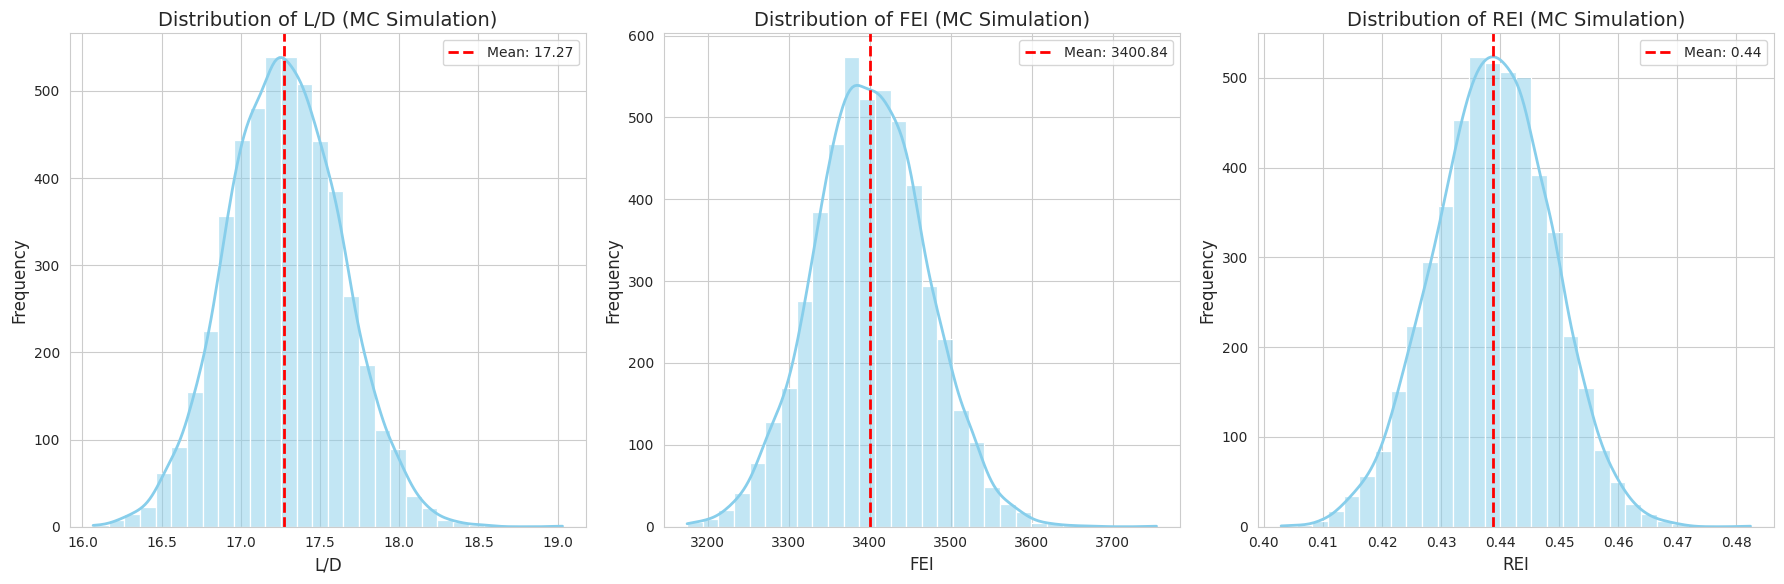


Confidence Intervals (95% Confidence Level):
  L/D: Mean = 17.2747, CI = [17.2648, 17.2845], Std Dev = 0.3557
  FEI: Mean = 3400.8363, CI = [3398.9158, 3402.7569], Std Dev = 69.2895
  REI: Mean = 0.4388, CI = [0.4385, 0.4390], Std Dev = 0.0098


In [55]:
def plot_uncertainty_histograms(df: pd.DataFrame, metrics: list[str]) -> None:
    """
    Plots histograms for specified performance metrics from Monte Carlo results.

    Args:
        df (pd.DataFrame): DataFrame with Monte Carlo simulation results.
        metrics (list[str]): List of performance metrics to plot (e.g., ['L/D', 'FEI', 'REI']).
    """
    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6), sharey=False)
    if num_metrics == 1:
        axes = [axes] # Ensure axes is iterable even for single plot

    for i, metric in enumerate(metrics):
        sns.histplot(df[metric], kde=True, bins=30, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {metric} (MC Simulation)', fontsize=14)
        axes[i].set_xlabel(metric, fontsize=12)
        axes[i].set_ylabel('Frequency', fontsize=12)
        axes[i].axvline(x=df[metric].mean(), color='red', linestyle='--', label=f'Mean: {df[metric].mean():.2f}')
        axes[i].legend()
    plt.tight_layout()
    plt.show()

print("Plotting uncertainty histograms...")
plot_uncertainty_histograms(mc_results_df, ['L/D', 'FEI', 'REI'])

def calculate_and_print_confidence_intervals(df: pd.DataFrame, metrics: list[str], alpha: float = 0.95) -> None:
    """
    Calculates and prints confidence intervals for specified performance metrics.

    Args:
        df (pd.DataFrame): DataFrame with Monte Carlo simulation results.
        metrics (list[str]): List of performance metrics.
        alpha (float): Confidence level (e.g., 0.95 for 95% CI).
    """
    print(f"\nConfidence Intervals ({(alpha*100):.0f}% Confidence Level):")
    for metric in metrics:
        mean_val = df[metric].mean()
        std_val = df[metric].std()
        # Calculate margin of error (assuming large enough sample size for Z-score approximation)
        # For 95% CI, Z-score is approx 1.96
        # For general alpha, use scipy.stats.norm.ppf(1 - (1-alpha)/2)
        from scipy.stats import norm
        z_score = norm.ppf(1 - (1 - alpha) / 2)
        margin_of_error = z_score * (std_val / np.sqrt(len(df)))

        lower_bound = mean_val - margin_of_error
        upper_bound = mean_val + margin_of_error

        print(f"  {metric}: Mean = {mean_val:.4f}, CI = [{lower_bound:.4f}, {upper_bound:.4f}], Std Dev = {std_val:.4f}")

calculate_and_print_confidence_intervals(mc_results_df, ['L/D', 'FEI', 'REI'])


## Sonuçların Yorumlanması ve Tasarımın Sağlamlığı

-   **Performans Dağılımı:** Monte Carlo simülasyonundan elde edilen histogramlar, belirsiz girdiler nedeniyle L/D, FEI ve REI gibi performans metriklerinin artık tek bir değer olmadığını, aksine bir dağılıma sahip olduğunu göstermektedir. Bu dağılımın genişliği, belirsizliğin performans üzerindeki etkisinin bir ölçüsüdür.
-   **Ortalama ve Güven Aralığı:** Performans metriklerinin ortalama değerleri, nominal tasarımın beklenen performansını yansıtır. Güven aralıkları ise, gerçek performansın belirli bir olasılıkla hangi aralıkta yer alacağını gösterir. Dar bir güven aralığı, tasarımın belirsizliklere karşı daha sağlam olduğunu, geniş bir aralık ise daha hassas olduğunu işaret eder.
-   **Risk Yönetimi:** Belirsizlik analizi, en kötü senaryo performansını (dağılımın alt kuyruğu) anlamamızı sağlar. Bu bilgi, mühendislerin tasarım kararları alırken risk toleransını belirlemesine ve olası performans düşüşlerine karşı önlemler almasına olanak tanır.

**Mühendislik Çıkarımı:** Bu analiz, nominal olarak 'optimal' kabul edilen bir tasarımın bile, gerçek dünyadaki belirsizlikler altında nasıl bir performans aralığı sunacağını gösterir. Bu, tasarım optimizasyonunda sadece en iyi performansı değil, aynı zamanda belirsizliklere karşı sağlamlığı da göz önünde bulundurmanın önemini vurgular. Vekil modeller, bu tür kapsamlı belirsizlik analizlerinin hızlı ve verimli bir şekilde yapılmasını sağlayarak tasarım döngüsünü hızlandırır.

# BÖLÜM 14 – BELİRSİZLİK ANALİZİ

Mühendislik tasarımında, her zaman bir miktar belirsizlik vardır. Girdi tasarım değişkenleri tam olarak bilinemeyebilir (üretim toleransları nedeniyle), veya fiziksel modelin kendisi basitleştirmeler ve varsayımlar içerdiğinden bazı parametrelerde belirsizlikler olabilir. Belirsizlik analizi, bu belirsizliklerin sistemin çıktısı (performansı) üzerindeki etkisini anlamamızı sağlar. Bu, tasarımın sağlamlığını değerlendirmek ve olası riskleri yönetmek için kritik öneme sahiptir.

Bu bölümde, seçilen girdi parametrelerindeki belirsizlikleri Monte Carlo simülasyonu kullanarak L/D oranı üzerindeki etkilerini inceleyeceğiz.

## Belirsizlik Kaynaklarının Tanımlanması

Basitleştirilmiş modelimizde, özellikle üretim toleransları ve model parametrelerinin gerçek dünyadaki değişkenliği nedeniyle bazı belirsizlikler olduğunu varsayacağız. Bu analiz için, aşağıdaki parametrelerde Gauss dağılımı şeklinde belirsizlikler olduğunu farz edeceğiz:

-   **Sıfır Kaldırma Sürükleme Katsayısı ($C_{D_0}$):** Uçak imalatındaki yüzey pürüzlülüğü, bağlantı elemanları vb. nedeniyle küçük değişiklikler gösterebilir.
-   **Oswald Verimlilik Faktörü ($E_{Oswald}$):** Kaldırma dağılımının ideal olmayışı veya kanat-gövde etkileşimleri nedeniyle değişiklik gösterebilir.
-   **Seyir Mach Sayısı ($M$):** Uçuş koşullarındaki küçük dalgalanmalar veya hedef Mach sayısındaki pilotaj kaynaklı sapmalar nedeniyle değişebilir.

Bu belirsizlikleri, nominal değerlerinin belirli bir yüzdesi civarında bir standart sapma ile modelleyeceğiz.

## Monte Carlo Simülasyonu

Monte Carlo simülasyonu, bir sistemin belirsiz girdiler altındaki davranışını istatistiksel olarak tahmin etmek için rastgele örneklemeyi kullanan bir hesaplama yöntemidir. Çok sayıda rastgele durum oluşturarak, çıktının olasılık dağılımını elde edebiliriz.

In [56]:
def run_monte_carlo_simulation(nominal_design: np.ndarray, num_mc_samples: int, model: AircraftPerformanceModel) -> pd.DataFrame:
    """
    Runs a Monte Carlo simulation to assess performance uncertainty.

    Args:
        nominal_design (np.ndarray): The base design variables (wing_area, aspect_ratio, taper_ratio, mach_number).
        num_mc_samples (int): Number of Monte Carlo samples to generate.
        model (AircraftPerformanceModel): Instance of the physics-based aircraft performance model.

    Returns:
        pd.DataFrame: DataFrame containing performance results for each MC sample.
    """
    wing_area_nom, aspect_ratio_nom, taper_ratio_nom, mach_number_nom = nominal_design

    # Define uncertainty distributions (e.g., Gaussian with a percentage standard deviation)
    # These are illustrative values
    uncertainty_params = {
        'C_D0_std_perc': 0.05,  # 5% std dev for C_D0
        'E_OSWALD_std_perc': 0.02, # 2% std dev for E_OSWALD
        'mach_number_std_perc': 0.01 # 1% std dev for Mach number
    }

    results = []
    for _ in range(num_mc_samples):
        # Sample from distributions for uncertain model parameters and design variables
        # Note: For simplicity, we are varying the model's internal parameters and a design variable.
        # In a real scenario, design variables (wing_area, aspect_ratio, taper_ratio) would also have uncertainties
        # due to manufacturing tolerances.

        # Perturb model parameters (create a temporary model for each MC run)
        mc_model = AircraftPerformanceModel()
        mc_model.C_D0 = np.random.normal(mc_model.C_D0, mc_model.C_D0 * uncertainty_params['C_D0_std_perc'])
        mc_model.E_OSWALD = np.random.normal(mc_model.E_OSWALD, mc_model.E_OSWALD * uncertainty_params['E_OSWALD_std_perc'])

        # Ensure parameters remain physically realistic
        mc_model.C_D0 = max(0.01, mc_model.C_D0)
        mc_model.E_OSWALD = min(0.95, max(0.6, mc_model.E_OSWALD))

        # Perturb Mach number (a design variable)
        perturbed_mach_number = np.random.normal(mach_number_nom, mach_number_nom * uncertainty_params['mach_number_std_perc'])
        # Ensure Mach number stays within bounds (e.g., defined in Section 2, or a reasonable range)
        perturbed_mach_number = min(0.85, max(0.75, perturbed_mach_number))

        performance = mc_model.calculate_performance(wing_area_nom, aspect_ratio_nom,
                                                     taper_ratio_nom, perturbed_mach_number)
        results.append(performance)

    return pd.DataFrame(results)

# Use the optimal design found from the physics model's global optimization
# The nominal design is 'Optimal Design Variables' from physics_de_optimization_results
nominal_design_variables = physics_de_optimization_results['best_design']

num_mc_samples = 5000
print(f"Running Monte Carlo simulation with {num_mc_samples} samples...")
mc_results_df = run_monte_carlo_simulation(nominal_design_variables, num_mc_samples, aircraft_model)

print("Monte Carlo simulation complete.")
print("First 5 rows of MC results:")
display(mc_results_df.head())

# Filter out results where L/D is very low, indicating non-physical conditions encountered during perturbation
mc_results_df = mc_results_df[mc_results_df['L/D'] > 0.011].copy()
print(f"Filtered {len(mc_results_df)} valid MC samples.")

Running Monte Carlo simulation with 5000 samples...
Monte Carlo simulation complete.
First 5 rows of MC results:


,CL,CD,L/D,FEI,REI
0,1.225003,0.069018,17.749150,3480.225569,0.452603
1,1.230510,0.072082,17.071039,3354.778189,0.434336
2,1.240178,0.067985,18.241904,3598.931178,0.462314
3,1.225003,0.072142,16.980414,3329.493038,0.433001
4,1.230536,0.073789,16.676505,3277.279211,0.424294


Filtered 5000 valid MC samples.


## Belirsizliğin Performans Üzerindeki Etkisinin Görselleştirilmesi

Monte Carlo simülasyonundan elde edilen performans metriklerinin dağılımlarını inceleyerek belirsizliğin L/D oranı üzerindeki etkisini anlayacağız. Histogramlar ve güven aralıkları (Confidence Intervals) bu analizin temelini oluşturacaktır.

Plotting uncertainty histograms...


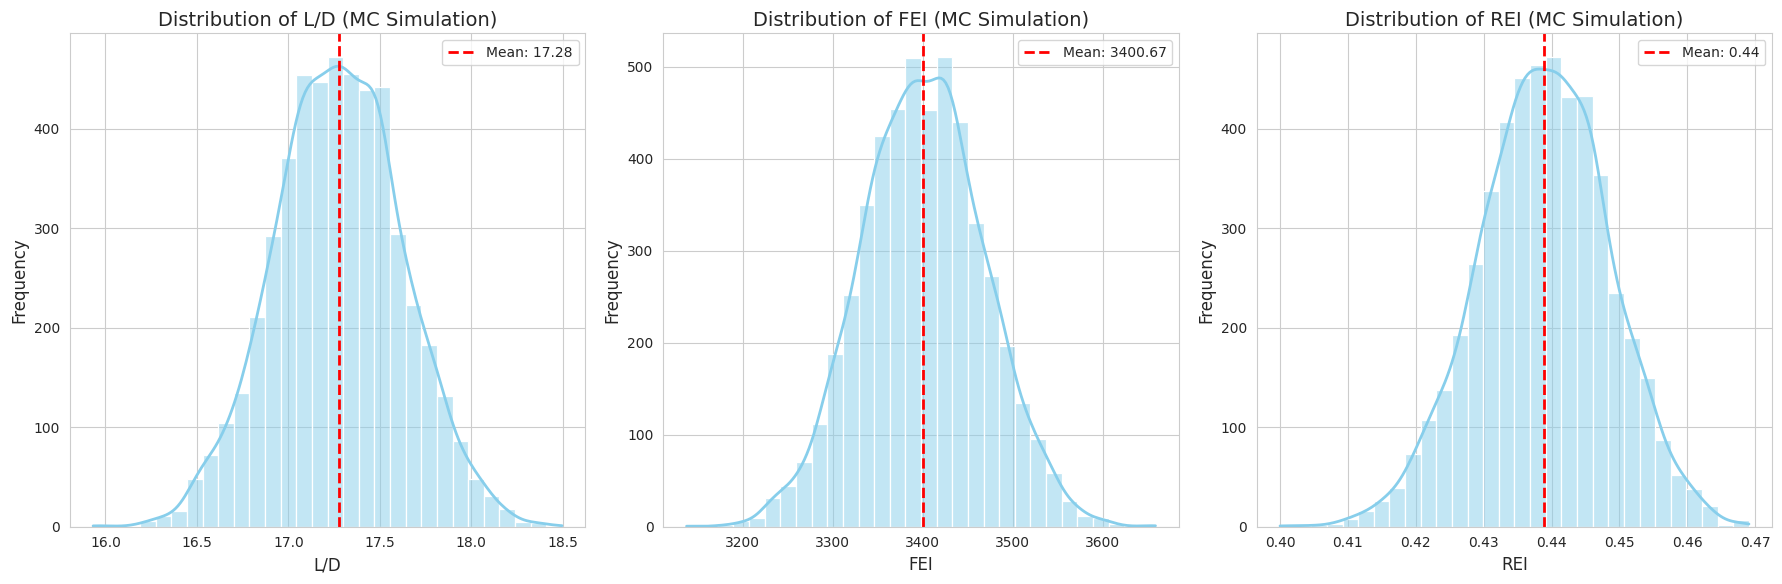


Confidence Intervals (95% Confidence Level):
  L/D: Mean = 17.2763, CI = [17.2666, 17.2859], Std Dev = 0.3493
  FEI: Mean = 3400.6693, CI = [3398.7873, 3402.5512], Std Dev = 67.8957
  REI: Mean = 0.4389, CI = [0.4386, 0.4391], Std Dev = 0.0096


In [57]:
def plot_uncertainty_histograms(df: pd.DataFrame, metrics: list[str]) -> None:
    """
    Plots histograms for specified performance metrics from Monte Carlo results.

    Args:
        df (pd.DataFrame): DataFrame with Monte Carlo simulation results.
        metrics (list[str]): List of performance metrics to plot (e.g., ['L/D', 'FEI', 'REI']).
    """
    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6), sharey=False)
    if num_metrics == 1:
        axes = [axes] # Ensure axes is iterable even for single plot

    for i, metric in enumerate(metrics):
        sns.histplot(df[metric], kde=True, bins=30, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {metric} (MC Simulation)', fontsize=14)
        axes[i].set_xlabel(metric, fontsize=12)
        axes[i].set_ylabel('Frequency', fontsize=12)
        axes[i].axvline(x=df[metric].mean(), color='red', linestyle='--', label=f'Mean: {df[metric].mean():.2f}')
        axes[i].legend()
    plt.tight_layout()
    plt.show()

print("Plotting uncertainty histograms...")
plot_uncertainty_histograms(mc_results_df, ['L/D', 'FEI', 'REI'])

def calculate_and_print_confidence_intervals(df: pd.DataFrame, metrics: list[str], alpha: float = 0.95) -> None:
    """
    Calculates and prints confidence intervals for specified performance metrics.

    Args:
        df (pd.DataFrame): DataFrame with Monte Carlo simulation results.
        metrics (list[str]): List of performance metrics.
        alpha (float): Confidence level (e.g., 0.95 for 95% CI).
    """
    print(f"\nConfidence Intervals ({(alpha*100):.0f}% Confidence Level):")
    for metric in metrics:
        mean_val = df[metric].mean()
        std_val = df[metric].std()
        # Calculate margin of error (assuming large enough sample size for Z-score approximation)
        # For 95% CI, Z-score is approx 1.96
        # For general alpha, use scipy.stats.norm.ppf(1 - (1-alpha)/2)
        from scipy.stats import norm
        z_score = norm.ppf(1 - (1 - alpha) / 2)
        margin_of_error = z_score * (std_val / np.sqrt(len(df)))

        lower_bound = mean_val - margin_of_error
        upper_bound = mean_val + margin_of_error

        print(f"  {metric}: Mean = {mean_val:.4f}, CI = [{lower_bound:.4f}, {upper_bound:.4f}], Std Dev = {std_val:.4f}")

calculate_and_print_confidence_intervals(mc_results_df, ['L/D', 'FEI', 'REI'])


## Sonuçların Yorumlanması ve Tasarımın Sağlamlığı

-   **Performans Dağılımı:** Monte Carlo simülasyonundan elde edilen histogramlar, belirsiz girdiler nedeniyle L/D, FEI ve REI gibi performans metriklerinin artık tek bir değer olmadığını, aksine bir dağılıma sahip olduğunu göstermektedir. Bu dağılımın genişliği, belirsizliğin performans üzerindeki etkisinin bir ölçüsüdür.
-   **Ortalama ve Güven Aralığı:** Performans metriklerinin ortalama değerleri, nominal tasarımın beklenen performansını yansıtır. Güven aralıkları ise, gerçek performansın belirli bir olasılıkla hangi aralıkta yer alacağını gösterir. Dar bir güven aralığı, tasarımın belirsizliklere karşı daha sağlam olduğunu, geniş bir aralık ise daha hassas olduğunu işaret eder.
-   **Risk Yönetimi:** Belirsizlik analizi, en kötü senaryo performansını (dağılımın alt kuyruğu) anlamamızı sağlar. Bu bilgi, mühendislerin tasarım kararları alırken risk toleransını belirlemesine ve olası performans düşüşlerine karşı önlemler almasına olanak tanır.

**Mühendislik Çıkarımı:** Bu analiz, nominal olarak 'optimal' kabul edilen bir tasarımın bile, gerçek dünyadaki belirsizlikler altında nasıl bir performans aralığı sunacağını gösterir. Bu, tasarım optimizasyonunda sadece en iyi performansı değil, aynı zamanda belirsizliklere karşı sağlamlığı da göz önünde bulundurmanın önemini vurgular. Vekil modeller, bu tür kapsamlı belirsizlik analizlerinin hızlı ve verimli bir şekilde yapılmasını sağlayarak tasarım döngüsünü hızlandırır.

# BÖLÜM 15 – KARAR ZEKASI PERSPEKTİFİ

Mühendislik tasarımı, karmaşık teknik zorlukların yanı sıra, ekonomik, operasyonel ve stratejik kararların birleşimidir. Geleneksel olarak, bu kararlar genellikle sınırlı bilgi ve sezgilere dayanarak verilir. Ancak veri, makine öğrenimi ve optimizasyon tekniklerinin entegrasyonuyla, daha bilinçli ve 'veri odaklı' karar verme süreçleri mümkün hale gelmektedir.

Karar Zekası (Decision Intelligence), bu teknikleri kullanarak mühendislik ve iş kararlarını optimize etme disiplinidir. Uçak tasarımında vekil modeller, bu kararların hızlı ve verimli bir şekilde alınmasında kritik bir rol oynar.

## Veri Odaklı Tasarım Akışı: Fizikten Karara

Bu not defterinde ele aldığımız süreç, modern mühendislik karar verme akışını özetlemektedir:

```
Fizik Tabanlı Model (Hassas ama Yavaş)
       ↓
Veri Üretimi ve Toplama
       ↓
Makine Öğrenimi Vekil Modelleri (Hızlı ve Yaklaşık)
       ↓
Tasarım Alanı Keşfi, Optimizasyon, Duyarlılık/Belirsizlik Analizi (Vekil Model Üzerinden)
       ↓
Bilgilendirilmiş Tasarım Kararları (Decision Intelligence)
```

Bu akış, mühendislerin daha fazla tasarım iterasyonunu daha kısa sürede keşfetmesini, potansiyel riskleri ve belirsizlikleri daha iyi anlamasını ve sonuç olarak daha sağlam ve optimal tasarımlara ulaşmasını sağlar.

## Vekil Modellerin Mühendislik Çabasını Azaltmadaki Rolü

Vekil modeller, mühendislik çabasını birkaç temel yolla önemli ölçüde azaltır:

1.  **Hesaplama Maliyetini Düşürme:** En pahalı simülasyonları veya deneyleri çok daha ucuz ve hızlı bir vekil modelle değiştirerek, aynı tasarım alanı keşfi için gereken süreyi ve kaynakları dramatik şekilde azaltır.
2.  **Tasarım İterasyonlarını Hızlandırma:** Tasarım döngüleri, vekil modeller sayesinde günler veya haftalar yerine dakikalar veya saniyeler içinde tamamlanabilir. Bu, mühendislerin "ne olurdu eğer" senaryolarını çok daha kolay incelemesine olanak tanır.
3.  **Daha Kapsamlı Tasarım Alanı Keşfi:** Geleneksel yöntemlerle mümkün olmayan geniş tasarım alanlarının sistematik olarak keşfedilmesini sağlar. Bu, daha yenilikçi ve yüksek performanslı çözümlerin keşfedilmesine yol açabilir.
4.  **Duyarlılık ve Belirsizlik Analizi:** Vekil modeller, tasarım parametrelerindeki belirsizliklerin veya değişikliklerin performans üzerindeki etkilerini hızlı ve verimli bir şekilde analiz etmeyi mümkün kılar. Bu, daha sağlam (robust) tasarımlar geliştirmek için kritik öneme sahiptir.
5.  **Karar Destek Sistemi:** Mühendislik parametreleri ile performans hedefleri arasındaki ilişkileri netleştirerek, tasarımcılara daha şeffaf ve veri odaklı kararlar almalarında yardımcı olur.

## Uygulama Alanları

Vekil modeller ve Karar Zekası prensipleri, havacılık ve uzay mühendisliğinde çok çeşitli alanlarda uygulanabilir:

-   **Uçak Ön Tasarımı:** Kavramsal aşamadan detay tasarıma kadar hızlı iterasyonlar.
-   **CFD ve FEA Optimizasyonu:** Yüksek doğruluklu simülasyonların maliyetini düşürerek aerodinamik şekil optimizasyonu veya yapısal optimizasyon.
-   **Malzeme Tasarımı:** Yeni malzemelerin özelliklerini tahmin etme ve optimize etme.
-   **Üretim Süreçlerinin Optimizasyonu:** Üretim parametrelerinin ürün kalitesi üzerindeki etkilerini anlama ve iyileştirme.
-   **Sistem Entegrasyonu ve MDO (Multidisciplinary Design Optimization):** Farklı disiplinler arası etkileşimleri yönetme ve optimize etme.

Bu yaklaşımlar, havacılık sektöründe tasarım ve geliştirme süreçlerini kökten değiştirme potansiyeline sahiptir.

# BÖLÜM 16 – İLERİ HAVACILIK UYGULAMALARI

Vekil modelleme, makine öğrenimi ve optimizasyon teknikleri, havacılık ve uzay mühendisliğinin birçok ileri alanında devrim niteliğinde uygulamalar bulmaktadır. Bu bölümde, bu tekniklerin kullanıldığı bazı önemli uygulama alanlarına kısaca değineceğiz.

## 1. CFD Vekil Modelleri (CFD Surrogate Models)

Hesaplamalı Akışkanlar Dinamiği (CFD) simülasyonları, uçak tasarımı ve analizi için temel bir araçtır ancak hesaplama açısından çok yoğun ve zaman alıcıdır. Bir CFD simülasyonunun tamamlanması saatler, hatta günler sürebilir.

CFD vekil modelleri, daha az sayıda tam CFD çalıştırmasından öğrenerek, binlerce tasarım konfigürasyonunun aerodinamik performansını anında tahmin edebilir. Bu, şekil optimizasyonu, kanat profili tasarımı ve aerodinamik karakteristiklerin hızlı değerlendirilmesi için kritik öneme sahiptir.

## 2. Yapısal Optimizasyon ve Topoloji Optimizasyonu

Uçak yapılarının hafifliği ve dayanıklılığı, yakıt verimliliği ve güvenlik açısından hayati öneme sahiptir. Sonlu Elemanlar Analizi (FEA) kullanılarak yapılan yapısal optimizasyonlar da CFD gibi hesaplama maliyeti yüksektir.

Vekil modeller, yapısal performansı (gerilme, deformasyon, burkulma) tahmin ederek yapısal optimizasyonu hızlandırır. Topoloji optimizasyonunda ise, bir tasarım alanı içinde malzemenin en verimli şekilde nasıl dağıtılacağını belirlemek için vekil modeller kullanılabilir, bu da ultra hafif ve yüksek performanslı yapılarla sonuçlanır.

## 3. Çok Disiplinli Tasarım Optimizasyonu (Multidisciplinary Design Optimization - MDO)

MDO, aerodinamik, yapısal, itki, kontrol ve maliyet gibi farklı mühendislik disiplinlerinin etkileşimini aynı anda optimize eden bir tasarım felsefesidir. Bu tür problemler son derece karmaşık ve büyük ölçeklidir.

Vekil modeller, her bir disiplin modelinin (örneğin, aerodinamik ve yapısal analiz) basitleştirilmiş ve hızlı tahmincileri olarak hareket ederek MDO sürecini yönetmek için vazgeçilmezdir. Bu, küresel optimuma daha verimli bir şekilde ulaşılmasını ve disiplinler arası ödünleşimlerin (trade-offs) daha iyi anlaşılmasını sağlar.

## 4. Dijital İkizler (Digital Twins)

Bir uçağın Dijital İkizi, operasyonel bir uçağın gerçek zamanlı sanal temsilidir. Performansını izlemek, bakım ihtiyaçlarını tahmin etmek ve gelecekteki görev senaryolarını simüle etmek için kullanılır.

Vekil modeller, dijital ikizlerin kalbinde yer alır. Fizik tabanlı modellerden öğrenilen ve güncellenen vekil modeller, uçağın performansı ve durumu hakkında hızlı ve doğru tahminler sağlayarak karar alma süreçlerini optimize eder ve operasyonel verimliliği artırır.

## 5. Hibrit-Elektrikli ve Tamamen Elektrikli Uçak Tasarımı

Havacılık endüstrisi, çevresel sürdürülebilirlik hedefleri doğrultusunda hibrit-elektrikli ve tamamen elektrikli uçaklara yönelmektedir. Bu yeni tahrik sistemleri, geleneksel uçaklardan farklı tasarım zorlukları ve optimizasyon problemleri sunar.

Vekil modeller, batarya ömrü, motor verimliliği, ısı yönetimi ve entegre sistem performansı gibi karmaşık parametreler arasındaki ilişkileri modellemek ve optimize etmek için kullanılır. Bu, yeni nesil elektrikli uçakların hızlı ve verimli bir şekilde tasarlanmasına ve geliştirilmesine yardımcı olur.

## 6. Otonom Tasarım Keşfi ve Üretken Tasarım (Generative Design)

Vekil modeller, tasarım alanını bağımsız olarak keşfedebilen ve yeni, potansiyel olarak yenilikçi tasarım çözümleri üretebilen otonom sistemlerin temelini oluşturur. Üretken tasarım, insan müdahalesi olmadan belirli performans hedeflerini karşılayan binlerce veya milyonlarca tasarım varyasyonu oluşturmak için yapay zeka ve vekil modelleri kullanır.

Bu, tasarımcılara daha önce hayal bile edilemeyen çözümler sunabilir ve yenilikçi aerodinamik veya yapısal konfigürasyonlara yol açabilir.

# BÖLÜM 17 – SON ÖZET

Bu not defteri, mühendislik tasarımında, özellikle havacılık alanında, vekil modelleme ve veri odaklı optimizasyonun gücünü göstermiştir. Geleneksel yaklaşımların yüksek hesaplama maliyetleri ve zaman alıcı doğası göz önüne alındığında, makine öğrenimi tabanlı vekil modeller, tasarım sürecini hızlandırmak, daha geniş tasarım alanlarını keşfetmek ve daha bilinçli kararlar almak için vazgeçilmez araçlar haline gelmiştir.

## Temel Makine Öğrenimi Dersleri

-   **Model Seçimi Önemlidir:** Problemin doğasına (doğrusal, doğrusal olmayan, karmaşık) uygun bir makine öğrenimi modeli seçmek kritik öneme sahiptir. `LinearRegression` basit ilişkiler için yeterli olabilirken, `RandomForestRegressor` veya `GradientBoostingRegressor` gibi topluluk öğrenme yöntemleri karmaşık ve doğrusal olmayan davranışları daha iyi yakalar.
-   **Veri Kalitesi ve Miktarı:** Vekil modellerin doğruluğu, eğitim verisinin kalitesine ve temsil gücüne doğrudan bağlıdır. Tasarım alanını iyi kapsayan, yeterli miktarda ve çeşitli veri noktaları, güvenilir modeller oluşturmanın temelidir.
-   **Ölçeklendirme:** Özellik ölçeklendirmesi (örneğin `StandardScaler` kullanarak), birçok makine öğrenimi algoritmasının (özellikle gradyan tabanlı olanlar ve Gaussian Süreçleri) performansını ve yakınsama hızını önemli ölçüde artırabilir.
-   **Model Doğrulaması:** Sadece sayısal metriklerle (RMSE, R²) yetinmeyip, artık grafikleri, tahmin-gerçek değer saçılım grafikleri gibi görsel doğrulama yöntemleriyle modelin davranışını derinlemesine anlamak, gizli sorunları tespit etmek için gereklidir.

## Temel Optimizasyon Dersleri

-   **Global vs. Yerel Optimum:** Yerel optimizasyon algoritmaları (`L-BFGS-B`), başlangıç noktasına duyarlıdır ve fonksiyonun yerel minimumlarına takılabilir. `Differential Evolution` gibi global optimizasyon algoritmaları, tüm tasarım alanını keşfetme eğiliminde olduğundan global optimumu bulma olasılığı daha yüksektir.
-   **Hesaplama Maliyeti:** Doğrudan fizik modeli üzerinde optimizasyon yapmak, doğru sonuçlar verse de, fonksiyon değerlendirmesi başına yüksek maliyet nedeniyle pratik olmayabilir. Vekil modeller, bu maliyeti dramatik bir şekilde düşürerek hızlı optimizasyon iterasyonlarına olanak tanır.
-   **Bayesçi Optimizasyon:** Özellikle fonksiyon değerlendirmelerinin çok pahalı olduğu durumlarda, Bayesçi Optimizasyon (Gaussian Süreçleri ve edinim fonksiyonları ile) en az sayıda değerlendirme ile optimuma ulaşmada üstün verimlilik sunar ve belirsizliği de hesaba katar.

## Temel Havacılık ve Vekil Modelleme Dersleri

-   **Fiziksel Anlayış:** Temel fizik tabanlı modelin davranışını ve aerodinamik prensipleri anlamak, veri analizlerini yorumlamak ve model seçimlerini yönlendirmek için önemlidir. Örneğin, Aspect Ratio'nun L/D üzerindeki güçlü etkisi, aerodinamik teoriden beklenen bir sonuçtur.
-   **Tasarım Alanı Keşfi:** Vekil modeller, mühendislerin daha geniş ve karmaşık tasarım alanlarını hızlıca görselleştirmesini ve keşfetmesini sağlar. Yanıt yüzeyleri, tasarım değişkenleri arasındaki etkileşimleri ve optimal bölgeleri göstererek değerli içgörüler sunar.
-   **Duyarlılık ve Belirsizlik:** Hangi tasarım değişkenlerinin performansı en çok etkilediğini anlamak (duyarlılık analizi) ve girdi belirsizliklerinin çıktı performansı üzerindeki etkisini değerlendirmek (belirsizlik analizi), daha sağlam ve güvenilir tasarımlar geliştirmek için kritiktir. Vekil modeller bu analizleri pratik hale getirir.
-   **Karar Zekası:** Vekil modeller, mühendislik karar verme süreçlerini veri odaklı hale getirir. Tasarım döngülerini hızlandırır, maliyetleri düşürür ve daha bilinçli, riske duyarlı tasarım seçimleri yapılmasını sağlar.

## Gelecekteki Uzantılar

Bu not defterinde ele alınan konular, daha ileri araştırmalar ve uygulamalar için bir başlangıç noktasıdır:

-   **Gelişmiş Vekil Modelleme Teknikleri:** Yapay Sinir Ağları (YSA), Kriging (Gaussian Süreçleri tabanlı), Polinomsal Yanıt Yüzeyleri (PRS) gibi daha gelişmiş vekil modelleme teknikleri kullanılabilir.
-   **Çok Amaçlı Optimizasyon:** Sadece L/D oranını değil, aynı zamanda ağırlık, menzil, yakıt tüketimi gibi birden fazla amacı aynı anda optimize eden çok amaçlı optimizasyon algoritmaları (örneğin, NSGA-II) entegre edilebilir.
-   **Tasarım Kısıtlamaları:** Modelimize performans veya tasarım değişkenleri üzerinde daha karmaşık kısıtlamalar (örneğin, kanat ağırlığı, kalkış mesafesi kısıtlamaları) eklenebilir.
-   **Dinamik Veri Toplama:** Tasarım alanı hakkında bilgi toplama ve vekil modelleri güncelleme sürecini optimize etmek için Aktif Öğrenme (Active Learning) stratejileri uygulanabilir.
-   **Gerçek Dünya Verileri:** Daha gerçekçi aerodinamik ve yapısal analizlerle entegrasyon veya gerçek uçuş test verileriyle modellerin doğrulanması.

---